<a href="https://colab.research.google.com/github/benjibrcz/deep-ltl-interp/blob/main/Timaeus_2026_Research_Scientist_Work_Test_(In_context_learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Timaeus \- Research Scientist \- Work Test 2026**

### **Background**

Large language models exhibit **in-context learning (ICL)**: they improve at prediction as they see more tokens within a single context, *without any weight updates*. There are several theoretical perspectives:

1. **ICL as in-context supervised learning**: Given question-answer pairs in the prompt, the model becomes more accurate at answering later questions.  
2. **ICL as in-context empirical risk minimization**: ICL occurs if the per-token loss decreases with context length.  
3. **ICL as in-context Bayesian inference**: ICL can be understood as approximate Bayesian inference over latent concepts or tasks.

You are **not expected** to be familiar with this literature.

---

### **Your Task**

Design and implement a prototype evaluation method to assess the in-context learning capabilities of transformers.

**Guiding questions:**

* What does it mean for a model to "learn" in-context? What does it mean for a model to *not* use in-context learning? What phenomena is ICL distinct from?   
* What tasks could reveal ICL? What properties should they have?  
* How do you measure ICL performance?  
* How do you control for confounds?

This is deliberately open-ended: you can focus on evaluating pretrained language models or on evaluating small transformers that you personally train from scratch on synthetic tasks; you can focus on evaluating a single model in detail or doing a broad comparative analysis; you can assume one of the three theoretical perspectives above and continue from there, or you can focus on comparing the three perspectives; etc. There is no "correct" way to approach this problem, and we recommend you spend some time thinking through options yourself. When you find yourself making choices about direction, please explain why you chose to focus on X over Y.

If you find yourself stuck, the references at the end of this document point to related work that may spark ideas. Please do not spend your entire work test reading papers.

---

### **What we’re looking for:**

* **Research thinking**: Clear problem formulation, awareness of confounds, thoughtful design  
* **Technical execution**: Working code, appropriate methods, correct implementation  
* **Communication**: Clear documentation, well-organized notebooks, interpretable results  
* **Depth vs. breadth**: Good decisions about what to pursue given time constraints

Feel free to decide to go deeper in some areas at the expense of others.


# 1. Design

## Overview

We evaluate ICL by presenting models with **k demonstration pairs** `(x_i, f(x_i))` followed by a
**test query** `x_test`, and measuring how well the model predicts `f(x_test)` as k increases.

## Model: Pythia family (EleutherAI)
- Available in sizes 70M → 6.9B (scaling analysis)
- Freely available, Colab-friendly
- Well-studied in ICL literature

## Tasks (synthetic, novel, ground-truth available)
1. **Arbitrary symbol mapping**: word → random integer
2. **Linear functions**: y = ax + b
3. **Modular arithmetic**: (a+b) mod p

## Confound controls (5 conditions per task)
| Condition | Description | Controls for |
|-----------|-------------|-------------|
| Standard | k correct demos | Baseline ICL |
| Irrelevant demos | k demos from different rule | "More context = better" |
| Shuffled labels | Same inputs, random outputs | Format imitation |
| Reversed order | Correct demos, reversed | Order sensitivity |
| Recency conflict | First half correct, second half wrong rule | Recency bias |

## Metrics (3 theoretical perspectives)
1. **Supervised learning**: Accuracy vs k
2. **ERM**: Per-token loss at answer position vs context length
3. **Bayesian**: Learning curve shape, permutation sensitivity

In [80]:
# Setup and imports
!pip install -q transformers accelerate

import torch
import numpy as np
import random
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda


In [81]:
# Results caching — saves experiment results to disk so we don't rerun on cell re-execution
import pickle, os

RESULTS_DIR = "results_cache"
os.makedirs(RESULTS_DIR, exist_ok=True)

def save_results(name, data):
    """Save results dict to disk."""
    with open(f"{RESULTS_DIR}/{name}.pkl", "wb") as f:
        pickle.dump(data, f)
    print(f"  [cache] Saved {name}")

def load_results(name):
    """Load results from cache, or return None if not cached."""
    path = f"{RESULTS_DIR}/{name}.pkl"
    if os.path.exists(path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        print(f"  [cache] Loaded {name} from cache")
        return data
    return None

print(f"Results cache dir: {RESULTS_DIR}/")

Results cache dir: results_cache/


In [82]:
# Load model and tokenizer
# Start with Pythia-410M as a reasonable middle ground for testing.
# Can scale up/down later for comparative analysis.

MODEL_NAME = "EleutherAI/pythia-410m"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16 if device.type == "cuda" else torch.float32,
).to(device)
model.eval()

print(f"Loaded {MODEL_NAME} ({sum(p.numel() for p in model.parameters()) / 1e6:.0f}M params)")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded EleutherAI/pythia-410m (405M params)


# 2. Metrics

Three metrics corresponding to the three theoretical perspectives on ICL:

1. **Accuracy vs k** (supervised learning view): Does the model get the right answer more often with more demos?
2. **Answer loss vs k** (ERM view): Does the cross-entropy loss on the answer tokens decrease with more demos?
3. **Bayesian diagnostics**: Is the learning curve log-linear? Is performance invariant to demo order?

In [83]:
@torch.no_grad()
def evaluate_prompt(model, tokenizer, prompt: str, target: str, device) -> dict:
    """Evaluate a single prompt+target pair.

    Returns:
        dict with:
            - 'accuracy': 1.0 if greedy-decoded answer matches target, else 0.0
            - 'loss': cross-entropy loss on the target tokens
            - 'generated': the model's greedy-decoded answer (for debugging)
    """
    # Tokenize prompt and target separately so we know where the answer starts
    prompt_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    target_ids = tokenizer.encode(target, add_special_tokens=False, return_tensors="pt").to(device)
    full_ids = torch.cat([prompt_ids, target_ids], dim=1)

    # Forward pass on full sequence
    outputs = model(full_ids)
    logits = outputs.logits  # (1, seq_len, vocab)

    # Loss on target tokens only:
    # logits at position [prompt_len-1 .. prompt_len+target_len-2] predict
    # tokens at position [prompt_len .. prompt_len+target_len-1]
    prompt_len = prompt_ids.shape[1]
    target_len = target_ids.shape[1]

    target_logits = logits[0, prompt_len - 1 : prompt_len + target_len - 1, :]  # (target_len, vocab)
    target_tokens = target_ids[0]  # (target_len,)

    loss = torch.nn.functional.cross_entropy(target_logits.float(), target_tokens).item()

    # Greedy decode: generate target_len tokens from prompt
    generated_ids = model.generate(
        prompt_ids,
        max_new_tokens=target_len,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    generated_text = tokenizer.decode(generated_ids[0, prompt_len:], skip_special_tokens=True).strip()
    accuracy = 1.0 if generated_text == target.strip() else 0.0

    return {
        "accuracy": accuracy,
        "loss": loss,
        "generated": generated_text,
    }


# Quick sanity check
result = evaluate_prompt(model, tokenizer, "The capital of France is", " Paris", device)
print(f"Sanity check - generated: '{result['generated']}', loss: {result['loss']:.3f}, acc: {result['accuracy']}")

Sanity check - generated: 'Paris', loss: 1.890, acc: 1.0


# 3. Datasets

## Task 1: Arbitrary Symbol Mapping

**Setup**: Map common English words to random single-digit integers (0-9).
Each "task instance" is a fresh random mapping. The model sees k demo pairs
like `"apple -> 7\nbanana -> 3\n"` and must predict the output for a held-out word.

**Why single digits?** Keeps the target to a single token, making accuracy/loss
clean to measure. The mapping is completely arbitrary — no semantic relationship
between words and numbers — so the model can't use pretraining knowledge.

**Word pool**: We use 50 common, unambiguous English nouns. For each task instance,
we sample a subset and assign random labels.

In [84]:
# Word pool: common, concrete, unambiguous English nouns
WORD_POOL = [
    "apple", "tiger", "river", "piano", "cloud", "bread", "chair", "flame",
    "grape", "horse", "knife", "lemon", "mouse", "ocean", "pearl", "queen",
    "robot", "snake", "torch", "whale", "arrow", "badge", "candy", "drum",
    "eagle", "fence", "globe", "heart", "ivory", "jewel", "koala", "lunar",
    "maple", "nerve", "olive", "pilot", "quilt", "reign", "storm", "tower",
    "union", "vapor", "wrist", "yacht", "zebra", "brick", "crane", "delta",
    "frost", "grain",
]

# K values to test (extended range)
K_VALUES = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]

# Labels for multi-class tasks (single tokens, alphabetical)
CLASS_LABELS = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")


class SymbolMappingTask:
    """Generates task instances for arbitrary word -> digit mapping."""

    def __init__(self, word_pool=WORD_POOL, n_labels=10, seed=None):
        self.word_pool = word_pool
        self.n_labels = n_labels
        self.rng = np.random.RandomState(seed)

    def sample_task(self, n_demos: int, n_test: int = 1):
        n_total = n_demos + n_test
        words = self.rng.choice(self.word_pool, size=n_total, replace=False).tolist()
        labels = self.rng.randint(0, self.n_labels, size=n_total).tolist()
        pairs = [(w, str(l)) for w, l in zip(words, labels)]
        return pairs[:n_demos], pairs[n_demos:]

    def sample_distractor_task(self, n_demos: int):
        words = self.rng.choice(self.word_pool, size=n_demos, replace=False).tolist()
        labels = self.rng.randint(0, self.n_labels, size=n_demos).tolist()
        return [(w, str(l)) for w, l in zip(words, labels)]


class MultiThresholdTask:
    """N-class threshold classification with controllable difficulty.

    Partitions numbers 0..(num_range-1) into n_classes intervals using
    (n_classes - 1) random thresholds. Each interval maps to a different
    class label (A, B, C, ...).

    Difficulty is controlled by n_classes:
      - n_classes=2: one threshold, binary (easy)
      - n_classes=4: three thresholds (medium)
      - n_classes=8: seven thresholds (hard)
      - n_classes=16: fifteen thresholds (very hard)

    Thresholds are constrained so each class covers at least 5% of the range,
    ensuring every class is represented in the demos.
    """

    def __init__(self, n_classes=2, num_range=1000, seed=None):
        self.n_classes = n_classes
        self.num_range = num_range
        self.labels = CLASS_LABELS[:n_classes]
        self.rng = np.random.RandomState(seed)

    def _sample_thresholds(self):
        """Sample n_classes-1 sorted thresholds with minimum spacing."""
        min_gap = max(self.num_range // (self.n_classes * 4), 2)  # ~5% of range per class minimum
        # Sample thresholds with rejection to ensure spacing
        for _ in range(1000):
            raw = sorted(self.rng.randint(min_gap, self.num_range - min_gap,
                                          size=self.n_classes - 1).tolist())
            # Check minimum gaps
            points = [0] + raw + [self.num_range]
            gaps = [points[i+1] - points[i] for i in range(len(points)-1)]
            if all(g >= min_gap for g in gaps):
                return raw
        # Fallback: evenly spaced
        step = self.num_range // self.n_classes
        return [step * (i + 1) for i in range(self.n_classes - 1)]

    def _classify(self, x, thresholds):
        """Classify a number given sorted thresholds."""
        for i, t in enumerate(thresholds):
            if x < t:
                return self.labels[i]
        return self.labels[-1]

    def sample_task(self, n_demos: int, n_test: int = 1):
        thresholds = self._sample_thresholds()
        n_total = n_demos + n_test
        xs = self.rng.choice(self.num_range, size=n_total, replace=False).tolist()
        pairs = [(str(x), self._classify(x, thresholds)) for x in xs]
        return pairs[:n_demos], pairs[n_demos:]

    def sample_distractor_task(self, n_demos: int):
        thresholds = self._sample_thresholds()  # different thresholds
        xs = self.rng.choice(self.num_range, size=n_demos, replace=False).tolist()
        return [(str(x), self._classify(x, thresholds)) for x in xs]


# Backwards compatibility: BinaryThresholdTask is just MultiThresholdTask with n_classes=2
def BinaryThresholdTask(num_range=1000, seed=None):
    return MultiThresholdTask(n_classes=2, num_range=num_range, seed=seed)


def format_demos(demos: list, test_word: str) -> str:
    """Format demo pairs + test query into a prompt string."""
    lines = [f"{word} -> {label}" for word, label in demos]
    lines.append(f"{test_word} ->")
    return "\n".join(lines)


# Quick tests
print("=== Symbol Mapping Task ===")
task_gen = SymbolMappingTask(seed=0)
demos, tests = task_gen.sample_task(n_demos=4, n_test=1)
print(format_demos(demos, tests[0][0]))
print(f"Expected: {tests[0][1]}\n")

print("=== Binary (2-class) ===")
task2 = MultiThresholdTask(n_classes=2, seed=0)
demos2, tests2 = task2.sample_task(n_demos=6, n_test=1)
print(format_demos(demos2, tests2[0][0]))
print(f"Expected: {tests2[0][1]}\n")

print("=== 4-class ===")
task4 = MultiThresholdTask(n_classes=4, seed=0)
demos4, tests4 = task4.sample_task(n_demos=8, n_test=1)
print(format_demos(demos4, tests4[0][0]))
print(f"Expected: {tests4[0][1]}")

=== Symbol Mapping Task ===
ivory -> 0
lemon -> 0
knife -> 4
vapor -> 5
river ->
Expected: 5

=== Binary (2-class) ===
708 -> A
533 -> A
298 -> A
356 -> A
833 -> B
553 -> A
27 ->
Expected: A

=== 4-class ===
710 -> B
666 -> B
298 -> B
356 -> B
571 -> B
836 -> C
27 -> A
231 -> A
306 ->
Expected: B


# 3.5 Confound Capability Benchmarks

Before testing for ICL, we verify the model **can already do** the simpler behaviors
that might explain apparent learning. If these are near-ceiling at low k, then any
ICL signal in the main experiments must go *beyond* these capabilities.

| Benchmark | What it tests | Expected |
|-----------|--------------|----------|
| **Format compliance** | Can the model output a valid label (A/B) given the format? | ~100% by k=1 |
| **Retrieval (copying)** | Can it copy the label for a word it's already seen in-context? | High at k=1 |
| **Majority label** | Does it output the most frequent label in the demos? | High at low k |
| **Recency copying** | Does it output the same label as the most recent demo? | Moderate-high |

In [85]:
BENCH_K_VALUES = [1, 2, 4, 8, 16, 32]
BENCH_N_TRIALS = 50
VALID_BINARY_LABELS = {"A", "B"}


def run_benchmarks(model, tokenizer, device, n_trials=BENCH_N_TRIALS):
    """Run all confound capability benchmarks.

    Returns a dict: benchmark_name -> {k -> list of result dicts}.
    Each result has 'accuracy' (benchmark-specific) and 'generated'.
    """
    rng = np.random.RandomState(789)
    results = defaultdict(lambda: defaultdict(list))

    for k in tqdm(BENCH_K_VALUES, desc="Benchmark k"):
        for trial in tqdm(range(n_trials), desc=f"k={k}", leave=False):

            # --- 1. FORMAT COMPLIANCE ---
            nums = rng.choice(1000, size=k + 1, replace=False).tolist()
            labels = [rng.choice(["A", "B"]) for _ in range(k)]
            demos = [(str(n), l) for n, l in zip(nums[:k], labels)]
            test_num = str(nums[k])
            prompt = format_demos(demos, test_num)
            res = evaluate_prompt(model, tokenizer, prompt, " A", device)
            is_valid = 1.0 if res["generated"].strip() in VALID_BINARY_LABELS else 0.0
            results["format_compliance"][k].append({
                "accuracy": is_valid, "generated": res["generated"]
            })

            # --- 2. RETRIEVAL (COPYING) ---
            nums = rng.choice(1000, size=k + 1, replace=False).tolist()
            threshold = rng.randint(200, 801)
            demos = [(str(n), "A" if n < threshold else "B") for n in nums[:k]]
            repeat_idx = rng.randint(0, k)
            test_num, correct_label = demos[repeat_idx]
            prompt = format_demos(demos, test_num)
            res = evaluate_prompt(model, tokenizer, prompt, f" {correct_label}", device)
            results["retrieval"][k].append({
                "accuracy": res["accuracy"], "generated": res["generated"]
            })

            # --- 3. MAJORITY LABEL ---
            majority_label = rng.choice(["A", "B"])
            nums = rng.choice(1000, size=k + 1, replace=False).tolist()
            demos = [(str(n), majority_label) for n in nums[:k]]
            test_num = str(nums[k])
            prompt = format_demos(demos, test_num)
            res = evaluate_prompt(model, tokenizer, prompt, f" {majority_label}", device)
            results["majority_label"][k].append({
                "accuracy": res["accuracy"], "generated": res["generated"]
            })

            # --- 4. RECENCY COPYING ---
            nums = rng.choice(1000, size=k + 1, replace=False).tolist()
            labels = [rng.choice(["A", "B"]) for _ in range(k)]
            demos = [(str(n), l) for n, l in zip(nums[:k], labels)]
            last_label = labels[-1]
            test_num = str(nums[k])
            prompt = format_demos(demos, test_num)
            res = evaluate_prompt(model, tokenizer, prompt, f" {last_label}", device)
            results["recency"][k].append({
                "accuracy": res["accuracy"], "generated": res["generated"]
            })

    return dict(results)


benchmark_results = load_results("benchmark_results")
if benchmark_results is None:
    benchmark_results = run_benchmarks(model, tokenizer, device)
    save_results("benchmark_results", benchmark_results)

  [cache] Loaded benchmark_results from cache


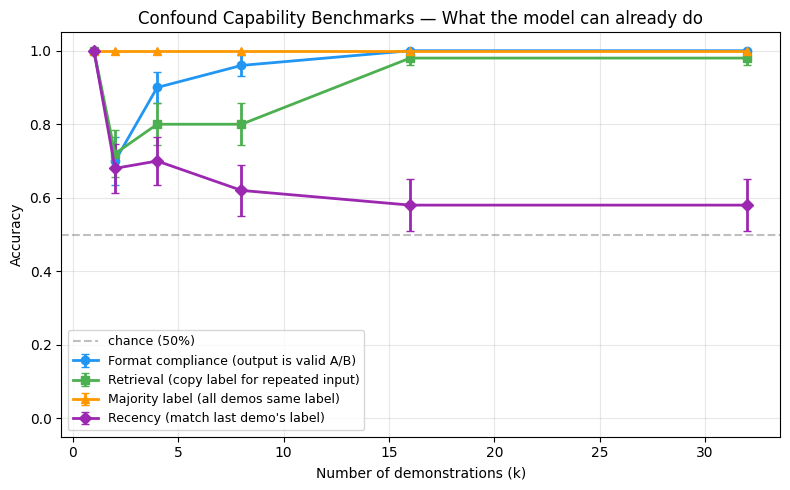


Benchmark summary (accuracy at each k):
  format_compliance    — k=1: 100%, k=2: 70%, k=4: 90%, k=8: 96%, k=16: 100%, k=32: 100%
  retrieval            — k=1: 100%, k=2: 72%, k=4: 80%, k=8: 80%, k=16: 98%, k=32: 98%
  majority_label       — k=1: 100%, k=2: 100%, k=4: 100%, k=8: 100%, k=16: 100%, k=32: 100%
  recency              — k=1: 100%, k=2: 68%, k=4: 70%, k=8: 62%, k=16: 58%, k=32: 58%


In [86]:
# Plot benchmark results
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

bench_colors = {
    "format_compliance": "#2196f3",
    "retrieval": "#4caf50",
    "majority_label": "#ff9800",
    "recency": "#9c27b0",
}
bench_markers = {
    "format_compliance": "o",
    "retrieval": "s",
    "majority_label": "^",
    "recency": "D",
}
bench_labels = {
    "format_compliance": "Format compliance (output is valid A/B)",
    "retrieval": "Retrieval (copy label for repeated input)",
    "majority_label": "Majority label (all demos same label)",
    "recency": "Recency (match last demo's label)",
}

for bench_name, k_results in benchmark_results.items():
    ks = sorted(k_results.keys())
    means = [np.mean([r["accuracy"] for r in k_results[k]]) for k in ks]
    sems = [np.std([r["accuracy"] for r in k_results[k]]) / np.sqrt(len(k_results[k])) for k in ks]

    ax.errorbar(
        ks, means, yerr=sems,
        label=bench_labels.get(bench_name, bench_name),
        color=bench_colors.get(bench_name, "gray"),
        marker=bench_markers.get(bench_name, "o"),
        capsize=3, linewidth=2,
    )

ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="chance (50%)")
ax.set_xlabel("Number of demonstrations (k)")
ax.set_ylabel("Accuracy")
ax.set_title("Confound Capability Benchmarks — What the model can already do")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary
print("\nBenchmark summary (accuracy at each k):")
for bench_name in ["format_compliance", "retrieval", "majority_label", "recency"]:
    k_results = benchmark_results[bench_name]
    ks = sorted(k_results.keys())
    vals = [f"k={k}: {np.mean([r['accuracy'] for r in k_results[k]]):.0%}" for k in ks]
    print(f"  {bench_name:20s} — {', '.join(vals)}")

In [87]:
def build_conditions(task_gen, k):
    """Build all 5 experimental conditions for a given k.

    Works with any task generator that has sample_task() and sample_distractor_task().

    Returns a list of (condition_name, prompt, target) tuples.
    Each call samples a fresh task instance so conditions share the same
    underlying mapping and test query.
    """
    if k == 0:
        _, tests = task_gen.sample_task(n_demos=0, n_test=1)
        test_word, test_label = tests[0]
        prompt = format_demos([], test_word)
        return [("standard", prompt, f" {test_label}")]

    demos, tests = task_gen.sample_task(n_demos=k, n_test=1)
    test_word, test_label = tests[0]
    target = f" {test_label}"

    # Collect the label vocabulary from this task instance
    all_labels = list(set(label for _, label in demos))

    conditions = []

    # 1. Standard: correct demos in original order
    prompt = format_demos(demos, test_word)
    conditions.append(("standard", prompt, target))

    # 2. Irrelevant demos: demos from a completely different mapping/rule
    irrel_demos = task_gen.sample_distractor_task(k)
    prompt = format_demos(irrel_demos, test_word)
    conditions.append(("irrelevant", prompt, target))

    # 3. Shuffled labels: same inputs, but labels randomly reassigned
    shuffled_labels = [all_labels[task_gen.rng.randint(0, len(all_labels))] for _ in demos]
    shuffled_demos = [(w, l) for (w, _), l in zip(demos, shuffled_labels)]
    prompt = format_demos(shuffled_demos, test_word)
    conditions.append(("shuffled_labels", prompt, target))

    # 4. Reversed order: correct demos, reversed
    reversed_demos = list(reversed(demos))
    prompt = format_demos(reversed_demos, test_word)
    conditions.append(("reversed", prompt, target))

    # 5. Recency conflict: first half correct, second half from wrong rule
    half = k // 2
    if half > 0:
        wrong_demos = task_gen.sample_distractor_task(k - half)
        conflict_demos = demos[:half] + wrong_demos
        prompt = format_demos(conflict_demos, test_word)
        conditions.append(("recency_conflict", prompt, target))

    return conditions


def run_experiment(model, tokenizer, device, task_gen, k_values, n_trials=50):
    """Run the full experiment across all k values and conditions."""
    results = defaultdict(lambda: defaultdict(list))

    for k in tqdm(k_values, desc="k values"):
        for trial in tqdm(range(n_trials), desc=f"k={k} trials", leave=False):
            conditions = build_conditions(task_gen, k)

            for cond_name, prompt, target in conditions:
                result = evaluate_prompt(model, tokenizer, prompt, target, device)
                result["k"] = k
                result["trial"] = trial
                results[cond_name][k].append(result)

    return dict(results)

# 5. Results

In [88]:
def plot_results(results, metric="loss", title_suffix="", chance_level=None):
    """Plot a metric across conditions and k values."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    colors = {
        "standard": "#2196f3",
        "irrelevant": "#f44336",
        "shuffled_labels": "#ff9800",
        "reversed": "#9c27b0",
        "recency_conflict": "#4caf50",
    }
    markers = {
        "standard": "o",
        "irrelevant": "x",
        "shuffled_labels": "s",
        "reversed": "^",
        "recency_conflict": "D",
    }

    for cond_name, k_results in results.items():
        ks = sorted(k_results.keys())
        means = [np.mean([r[metric] for r in k_results[k]]) for k in ks]
        sems = [np.std([r[metric] for r in k_results[k]]) / np.sqrt(len(k_results[k])) for k in ks]

        ax.errorbar(
            ks, means, yerr=sems,
            label=cond_name,
            color=colors.get(cond_name, "gray"),
            marker=markers.get(cond_name, "o"),
            capsize=3,
            linewidth=2,
        )

    ax.set_xlabel("Number of demonstrations (k)")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"{metric.capitalize()} vs k {title_suffix}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    if metric == "accuracy" and chance_level is not None:
        ax.axhline(y=chance_level, color="gray", linestyle="--", alpha=0.5,
                    label=f"chance ({chance_level:.0%})")
        ax.set_ylim(-0.05, 1.05)
        ax.legend()

    plt.tight_layout()
    plt.show()

  [cache] Loaded results_t1 from cache


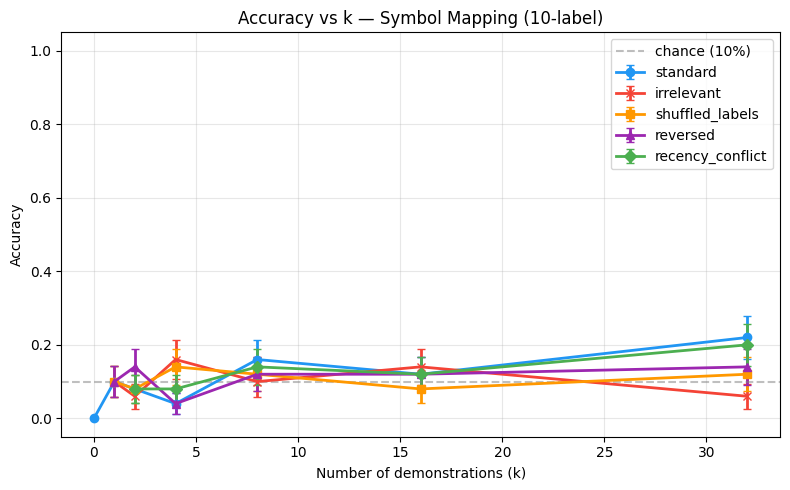

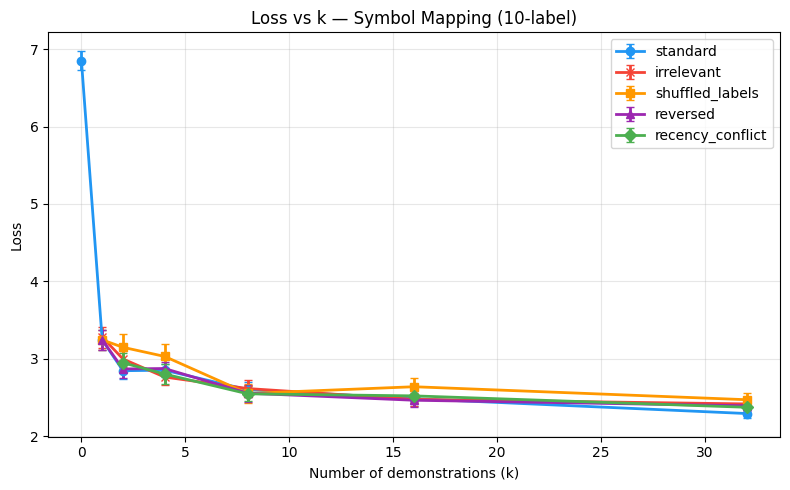

In [89]:
# Full run: Task 1 (Symbol Mapping, 10-label)
# Capped at k=32 because word pool has only 50 words

results_t1 = load_results("results_t1")
if results_t1 is None:
    task_gen_full = SymbolMappingTask(seed=123)
    results_t1 = run_experiment(
        model, tokenizer, device, task_gen_full,
        k_values=[0, 1, 2, 4, 8, 16, 32],
        n_trials=50,
    )
    save_results("results_t1", results_t1)

plot_results(results_t1, metric="accuracy", title_suffix="— Symbol Mapping (10-label)", chance_level=0.1)
plot_results(results_t1, metric="loss", title_suffix="— Symbol Mapping (10-label)")

## Task 2: Binary Threshold Classification

**Setup**: Numbers 0-99 are classified as "A" or "B" based on a random threshold t.
If x < t → "A", else → "B". The threshold is randomly chosen per task instance
from [20, 80] to ensure both classes are well-represented.

**Why this is better for detecting ICL**:
- **Binary** → chance is 50%, so any improvement is easy to detect
- **Learnable rule** → the model can infer the threshold from examples (not pure memorization)
- **Unlimited inputs** → supports large k (up to 256)
- **Novel each time** → different threshold per task, can't be memorized from pretraining

  [cache] Loaded results_t2 from cache


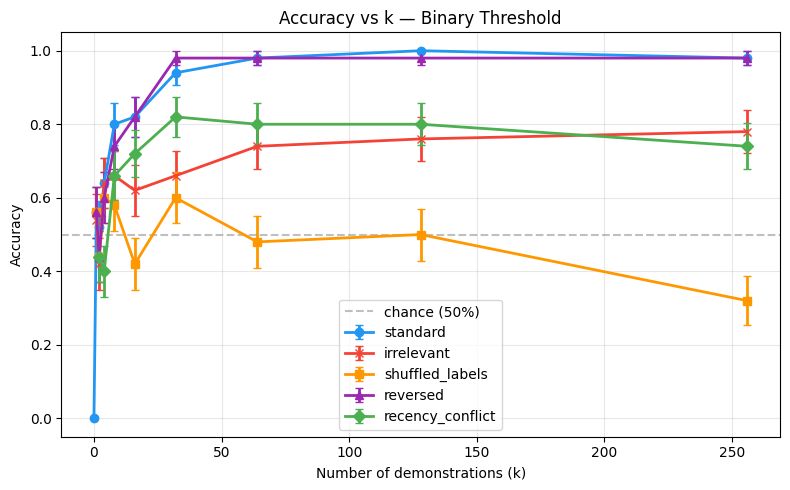

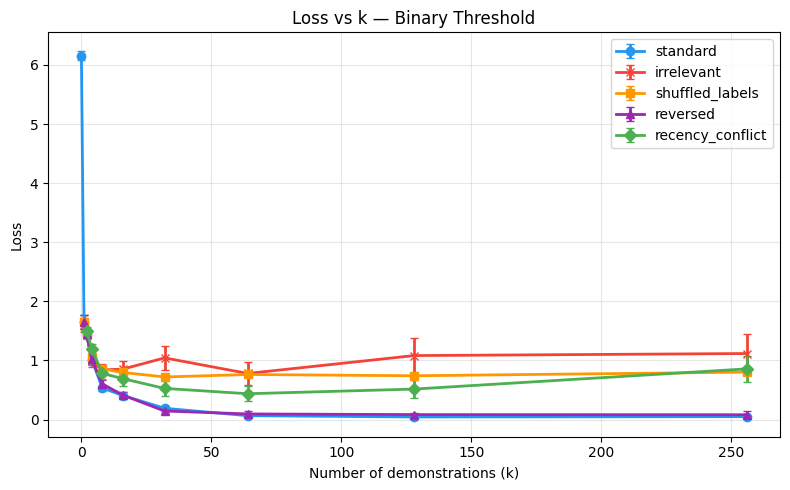

In [90]:
# Full run: Task 2 (Binary Threshold Classification)
# Extended k range — binary task supports large k

results_t2 = load_results("results_t2")
if results_t2 is None:
    task_gen_binary = BinaryThresholdTask(seed=456)
    results_t2 = run_experiment(
        model, tokenizer, device, task_gen_binary,
        k_values=K_VALUES,  # [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
        n_trials=50,
    )
    save_results("results_t2", results_t2)

plot_results(results_t2, metric="accuracy", title_suffix="— Binary Threshold", chance_level=0.5)
plot_results(results_t2, metric="loss", title_suffix="— Binary Threshold")

## Task 3: Difficulty Sweep — Multi-Threshold Classification

We use `MultiThresholdTask` to sweep across **number of latent classes** N = {2, 3, 4, 6, 8, 12, 16}.
All tasks use the same structure: partition numbers 0-999 into N intervals with random boundaries.
The model must learn N-1 thresholds from demonstrations.

**Key question**: How does ICL performance degrade with task difficulty (number of classes)?

For this sweep we only run the **standard** condition (correct demos, no confound controls)
to keep runtime manageable. We plot accuracy vs k for each N, normalized against chance (1/N).

In [91]:
# Difficulty sweep: standard condition only, varying n_classes
N_CLASSES_SWEEP = [2, 3, 4, 6, 8, 12, 16]
SWEEP_K_VALUES = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
SWEEP_N_TRIALS = 50

difficulty_results = load_results("difficulty_results")
if difficulty_results is None:
    difficulty_results = {}  # n_classes -> {k -> list of result dicts}

    for n_classes in tqdm(N_CLASSES_SWEEP, desc="n_classes sweep"):
        task_gen = MultiThresholdTask(n_classes=n_classes, seed=100 + n_classes)
        k_results = defaultdict(list)

        for k in tqdm(SWEEP_K_VALUES, desc=f"N={n_classes}", leave=False):
            for trial in range(SWEEP_N_TRIALS):
                demos, tests = task_gen.sample_task(n_demos=k, n_test=1)
                test_word, test_label = tests[0]
                prompt = format_demos(demos, test_word)
                target = f" {test_label}"
                result = evaluate_prompt(model, tokenizer, prompt, target, device)
                result["k"] = k
                k_results[k].append(result)

        difficulty_results[n_classes] = dict(k_results)

    save_results("difficulty_results", difficulty_results)
    print("Difficulty sweep complete.")

  [cache] Loaded difficulty_results from cache


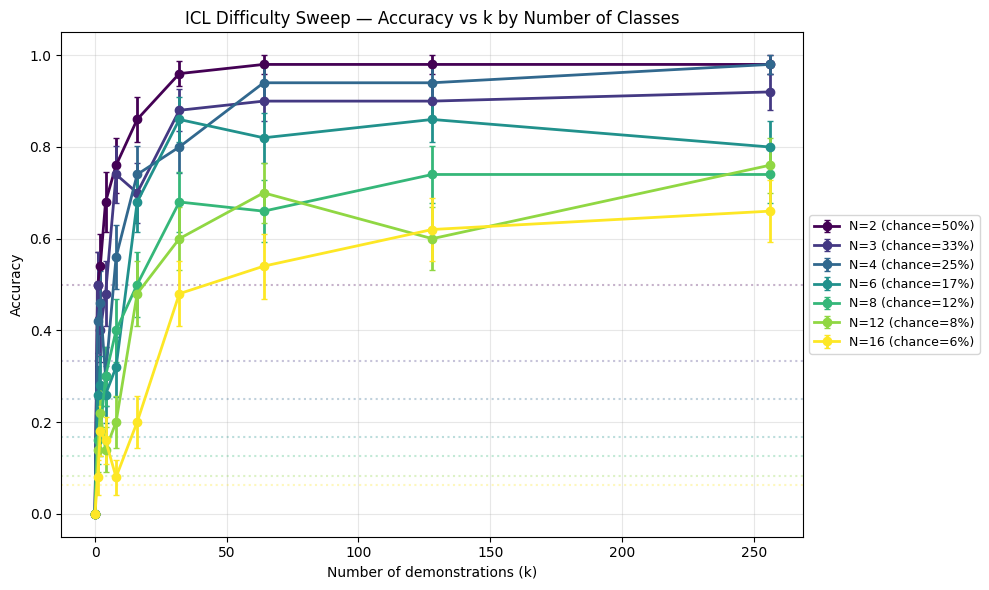

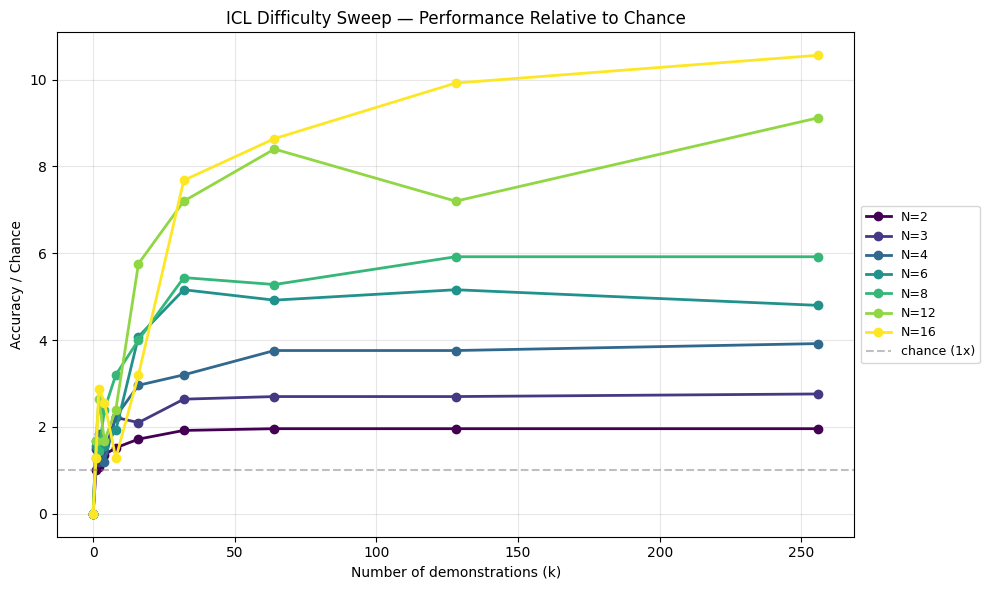


Max accuracy reached (at k=256):
  N= 2: acc=98.0%, chance=50.0%, ratio=2.0x
  N= 3: acc=92.0%, chance=33.3%, ratio=2.8x
  N= 4: acc=98.0%, chance=25.0%, ratio=3.9x
  N= 6: acc=80.0%, chance=16.7%, ratio=4.8x
  N= 8: acc=74.0%, chance=12.5%, ratio=5.9x
  N=12: acc=76.0%, chance=8.3%, ratio=9.1x
  N=16: acc=66.0%, chance=6.2%, ratio=10.6x


In [92]:
# Plot 1: Raw accuracy vs k for each n_classes
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

cmap = plt.cm.viridis
colors_sweep = {n: cmap(i / (len(N_CLASSES_SWEEP) - 1)) for i, n in enumerate(N_CLASSES_SWEEP)}

for n_classes in N_CLASSES_SWEEP:
    k_results = difficulty_results[n_classes]
    ks = sorted(k_results.keys())
    means = [np.mean([r["accuracy"] for r in k_results[k]]) for k in ks]
    sems = [np.std([r["accuracy"] for r in k_results[k]]) / np.sqrt(len(k_results[k])) for k in ks]
    chance = 1.0 / n_classes

    ax.errorbar(ks, means, yerr=sems, label=f"N={n_classes} (chance={chance:.0%})",
                color=colors_sweep[n_classes], marker="o", capsize=2, linewidth=2)
    ax.axhline(y=chance, color=colors_sweep[n_classes], linestyle=":", alpha=0.3)

ax.set_xlabel("Number of demonstrations (k)")
ax.set_ylabel("Accuracy")
ax.set_title("ICL Difficulty Sweep — Accuracy vs k by Number of Classes")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Accuracy normalized by chance (how many times better than random)
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for n_classes in N_CLASSES_SWEEP:
    k_results = difficulty_results[n_classes]
    ks = sorted(k_results.keys())
    chance = 1.0 / n_classes
    means = [np.mean([r["accuracy"] for r in k_results[k]]) / chance for k in ks]

    ax.plot(ks, means, label=f"N={n_classes}",
            color=colors_sweep[n_classes], marker="o", linewidth=2)

ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="chance (1x)")
ax.set_xlabel("Number of demonstrations (k)")
ax.set_ylabel("Accuracy / Chance")
ax.set_title("ICL Difficulty Sweep — Performance Relative to Chance")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\nMax accuracy reached (at k=256):")
for n_classes in N_CLASSES_SWEEP:
    k_results = difficulty_results[n_classes]
    max_k = max(k_results.keys())
    acc = np.mean([r["accuracy"] for r in k_results[max_k]])
    chance = 1.0 / n_classes
    print(f"  N={n_classes:2d}: acc={acc:.1%}, chance={chance:.1%}, ratio={acc/chance:.1f}x")

## Model Size Comparison

We repeat the difficulty sweep for **Pythia-160M** (smaller) and **Pythia-1.4B** (larger)
to test whether ICL capability scales with model size.

Key prediction: larger models should
1. Reach higher accuracy at the same k
2. Handle more classes before performance degrades
3. Need fewer demonstrations to saturate

We load models one at a time to avoid OOM, run the same sweep, then compare.

In [93]:
def run_difficulty_sweep(model, tokenizer, device, n_classes_list, k_values, n_trials=50):
    """Run the difficulty sweep for a single model. Returns {n_classes -> {k -> [results]}}."""
    all_results = {}
    for n_classes in tqdm(n_classes_list, desc="n_classes"):
        task_gen = MultiThresholdTask(n_classes=n_classes, seed=100 + n_classes)
        k_results = defaultdict(list)
        for k in tqdm(k_values, desc=f"N={n_classes}", leave=False):
            for trial in range(n_trials):
                demos, tests = task_gen.sample_task(n_demos=k, n_test=1)
                test_word, test_label = tests[0]
                prompt = format_demos(demos, test_word)
                target = f" {test_label}"
                result = evaluate_prompt(model, tokenizer, prompt, target, device)
                result["k"] = k
                k_results[k].append(result)
        all_results[n_classes] = dict(k_results)
    return all_results


def load_model(model_name, device):
    """Load a model and tokenizer, return (model, tokenizer, param_count_str)."""
    tok = AutoTokenizer.from_pretrained(model_name)
    tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        model_name,
        dtype=torch.float16 if device.type == "cuda" else torch.float32,
    ).to(device)
    mdl.eval()
    n_params = sum(p.numel() for p in mdl.parameters()) / 1e6
    print(f"Loaded {model_name} ({n_params:.0f}M params)")
    return mdl, tok, f"{n_params:.0f}M"


scaling_results = load_results("scaling_results")
if scaling_results is None:
    # Store results from the 410M run we already have
    scaling_results = {"410M": difficulty_results}

    # --- Pythia-160M ---
    print("=" * 50)
    print("Running Pythia-160M...")
    del model  # free memory
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    model_sm, tok_sm, label_sm = load_model("EleutherAI/pythia-160m", device)
    scaling_results[label_sm] = run_difficulty_sweep(
        model_sm, tok_sm, device,
        n_classes_list=N_CLASSES_SWEEP,
        k_values=SWEEP_K_VALUES,
        n_trials=SWEEP_N_TRIALS,
    )
    del model_sm
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    # --- Pythia-1.4B ---
    print("=" * 50)
    print("Running Pythia-1.4B...")

    model_lg, tok_lg, label_lg = load_model("EleutherAI/pythia-1.4b", device)
    scaling_results[label_lg] = run_difficulty_sweep(
        model_lg, tok_lg, device,
        n_classes_list=N_CLASSES_SWEEP,
        k_values=SWEEP_K_VALUES,
        n_trials=SWEEP_N_TRIALS,
    )
    del model_lg
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

    save_results("scaling_results", scaling_results)
    print("\nModel scaling sweep complete.")

# Reload 410M for further experiments (needed regardless of cache)
model, tokenizer, _ = load_model("EleutherAI/pythia-410m", device)

  [cache] Loaded scaling_results from cache


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded EleutherAI/pythia-410m (405M params)


/tmp/ipython-input-2921009093.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap = plt.cm.get_cmap("tab10", max(len(model_labels_sorted), 3))


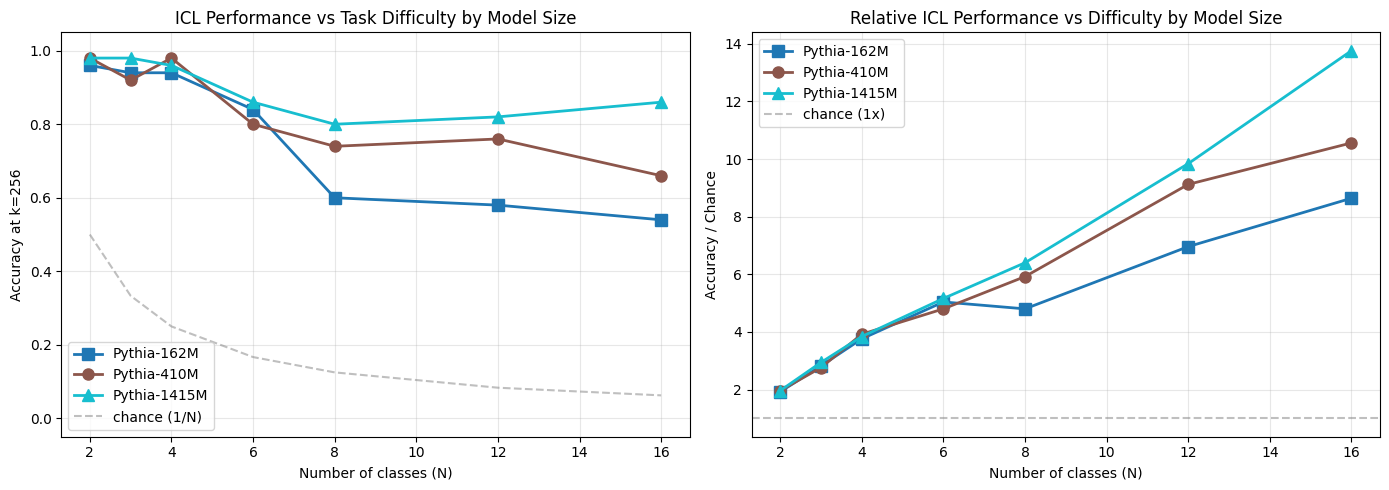

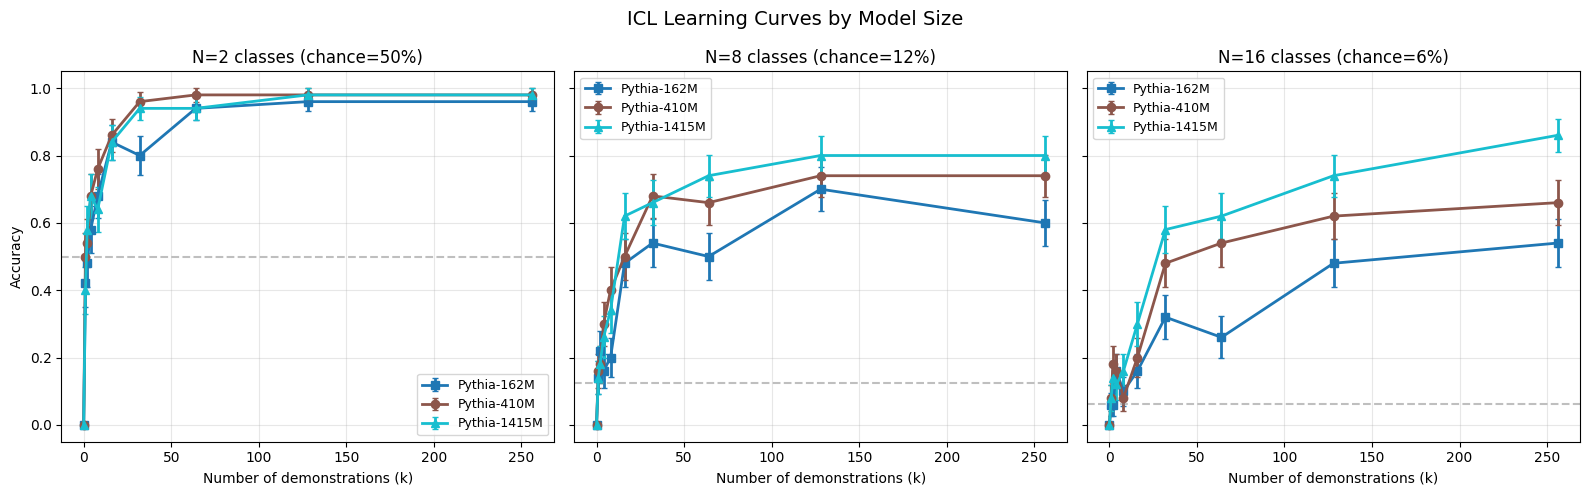


Accuracy at k=256 by model size and n_classes:
   N      162M      410M     1415M   chance
   2    96.0%    98.0%    98.0%   50.0%
   3    94.0%    92.0%    98.0%   33.3%
   4    94.0%    98.0%    96.0%   25.0%
   6    84.0%    80.0%    86.0%   16.7%
   8    60.0%    74.0%    80.0%   12.5%
  12    58.0%    76.0%    82.0%    8.3%
  16    54.0%    66.0%    86.0%    6.2%


In [105]:
# Plot 1: Accuracy at k=256 vs n_classes, for each model size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalize label names (the param count might vary slightly)
model_labels_sorted = sorted(scaling_results.keys(),
                              key=lambda x: float(x.replace("M", "").replace("B", "000")))

# Assign colors dynamically so every model gets a unique color
_cmap = plt.cm.get_cmap("tab10", max(len(model_labels_sorted), 3))
model_colors = {label: _cmap(i) for i, label in enumerate(model_labels_sorted)}
_markers = ["s", "o", "^", "D", "v", "p"]
model_markers = {label: _markers[i % len(_markers)] for i, label in enumerate(model_labels_sorted)}

# --- Panel 1: Raw accuracy at k=256 ---
ax = axes[0]
for model_label in model_labels_sorted:
    diff_results = scaling_results[model_label]
    n_classes_list = sorted(diff_results.keys())
    accs = []
    for n in n_classes_list:
        max_k = max(diff_results[n].keys())
        acc = np.mean([r["accuracy"] for r in diff_results[n][max_k]])
        accs.append(acc)

    color = model_colors[model_label]
    marker = model_markers[model_label]
    ax.plot(n_classes_list, accs, label=f"Pythia-{model_label}",
            color=color, marker=marker, linewidth=2, markersize=8)

# Plot chance level
n_range = sorted(list(scaling_results.values())[0].keys())
ax.plot(n_range, [1.0/n for n in n_range], label="chance (1/N)",
        color="gray", linestyle="--", alpha=0.5)

ax.set_xlabel("Number of classes (N)")
ax.set_ylabel("Accuracy at k=256")
ax.set_title("ICL Performance vs Task Difficulty by Model Size")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# --- Panel 2: Chance-normalized accuracy at k=256 ---
ax = axes[1]
for model_label in model_labels_sorted:
    diff_results = scaling_results[model_label]
    n_classes_list = sorted(diff_results.keys())
    ratios = []
    for n in n_classes_list:
        max_k = max(diff_results[n].keys())
        acc = np.mean([r["accuracy"] for r in diff_results[n][max_k]])
        ratios.append(acc / (1.0 / n))

    color = model_colors[model_label]
    marker = model_markers[model_label]
    ax.plot(n_classes_list, ratios, label=f"Pythia-{model_label}",
            color=color, marker=marker, linewidth=2, markersize=8)

ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="chance (1x)")
ax.set_xlabel("Number of classes (N)")
ax.set_ylabel("Accuracy / Chance")
ax.set_title("Relative ICL Performance vs Difficulty by Model Size")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Plot 3: Learning curves for selected difficulties, all models ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
selected_n = [2, 8, 16]

for idx, n_classes in enumerate(selected_n):
    ax = axes[idx]
    chance = 1.0 / n_classes

    for model_label in model_labels_sorted:
        diff_results = scaling_results[model_label]
        if n_classes not in diff_results:
            continue
        k_results = diff_results[n_classes]
        ks = sorted(k_results.keys())
        means = [np.mean([r["accuracy"] for r in k_results[k]]) for k in ks]
        sems = [np.std([r["accuracy"] for r in k_results[k]]) / np.sqrt(len(k_results[k])) for k in ks]

        color = model_colors[model_label]
        marker = model_markers[model_label]
        ax.errorbar(ks, means, yerr=sems, label=f"Pythia-{model_label}",
                    color=color, marker=marker, capsize=2, linewidth=2)

    ax.axhline(y=chance, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Number of demonstrations (k)")
    ax.set_title(f"N={n_classes} classes (chance={chance:.0%})")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.set_ylabel("Accuracy")
    ax.legend(fontsize=9)

plt.suptitle("ICL Learning Curves by Model Size", fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print("\nAccuracy at k=256 by model size and n_classes:")
header = f"{'N':>4s}" + "".join(f"  {ml:>8s}" for ml in model_labels_sorted) + "   chance"
print(header)
for n in sorted(list(scaling_results.values())[0].keys()):
    row = f"{n:4d}"
    for ml in model_labels_sorted:
        if n in scaling_results[ml]:
            max_k = max(scaling_results[ml][n].keys())
            acc = np.mean([r["accuracy"] for r in scaling_results[ml][n][max_k]])
            row += f"  {acc:>7.1%}"
        else:
            row += f"  {'N/A':>7s}"
    row += f"  {1.0/n:>6.1%}"
    print(row)

## Bayesian Inference Diagnostics

We test whether the ICL learning curves are better described by **Bayesian inference** (exponential loss decay) or a **power law** (non-Bayesian):

| Model | Prediction | Diagnostic |
|-------|-----------|------------|
| **Bayesian** | Loss decays exponentially: L(k) ~ exp(-βk) | log(L) vs k is **linear** |
| **Power law** | Loss decays as power law: L(k) ~ k^(-α) | log(L) vs log(k) is **linear** |

We also check **sample complexity scaling**: Bayesian theory predicts the number of demos needed scales linearly with the number of classes N.

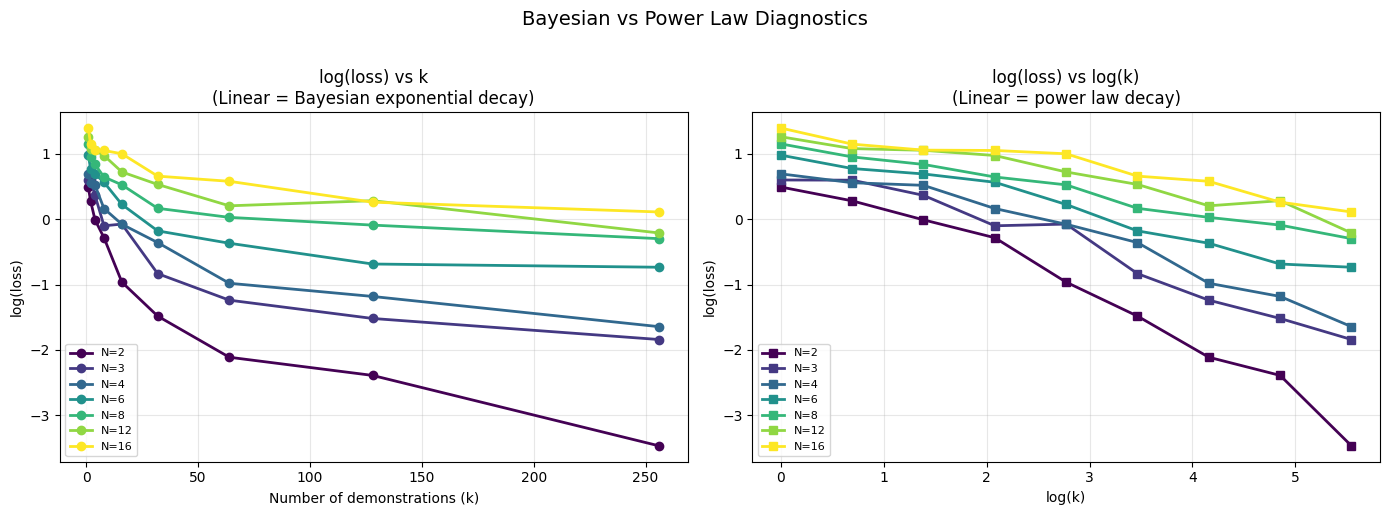

Model Fit Comparison: Exponential (Bayesian) vs Power Law
   N     R²(exp)   R²(power)      Better   exp slope  pow exponent
----------------------------------------------------------------------
   2      0.7975      0.9667   Power law    -0.01420       -0.7033
   3      0.7185      0.9611   Power law    -0.00926       -0.4820
   4      0.7873      0.9583   Power law    -0.00876       -0.4348
   6      0.6656      0.9729   Power law    -0.00623       -0.3391
   8      0.6713      0.9897   Power law    -0.00485       -0.2652
  12      0.7799      0.9427   Power law    -0.00506       -0.2505
  16      0.7838      0.9429   Power law    -0.00446       -0.2199


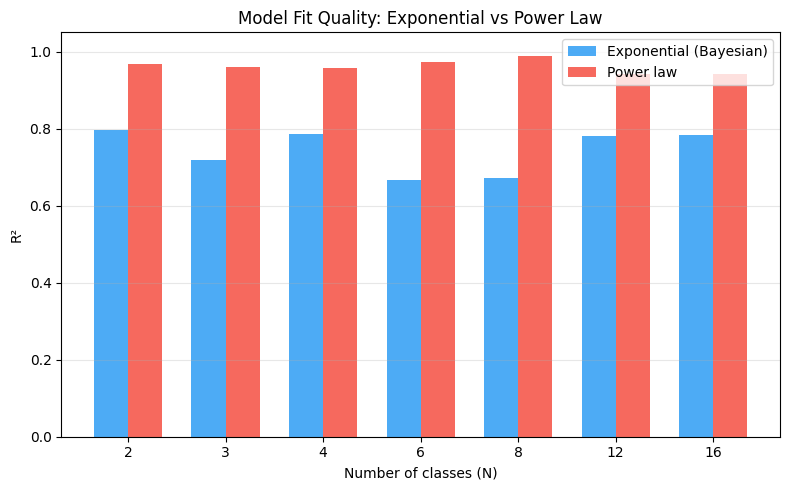

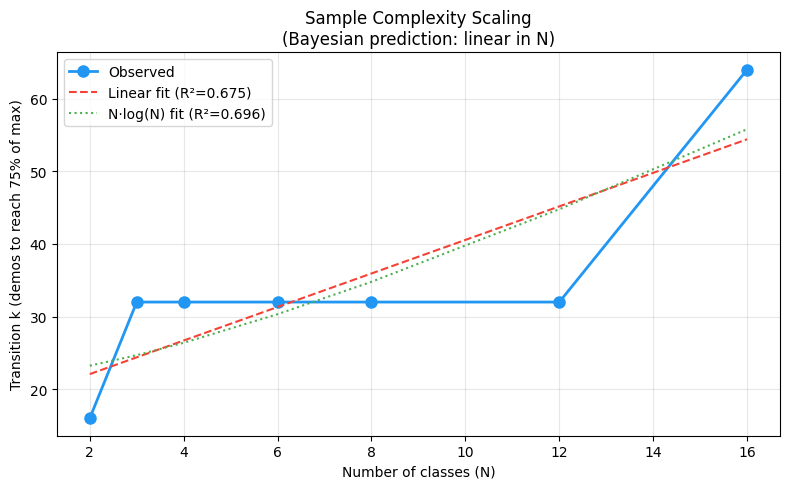

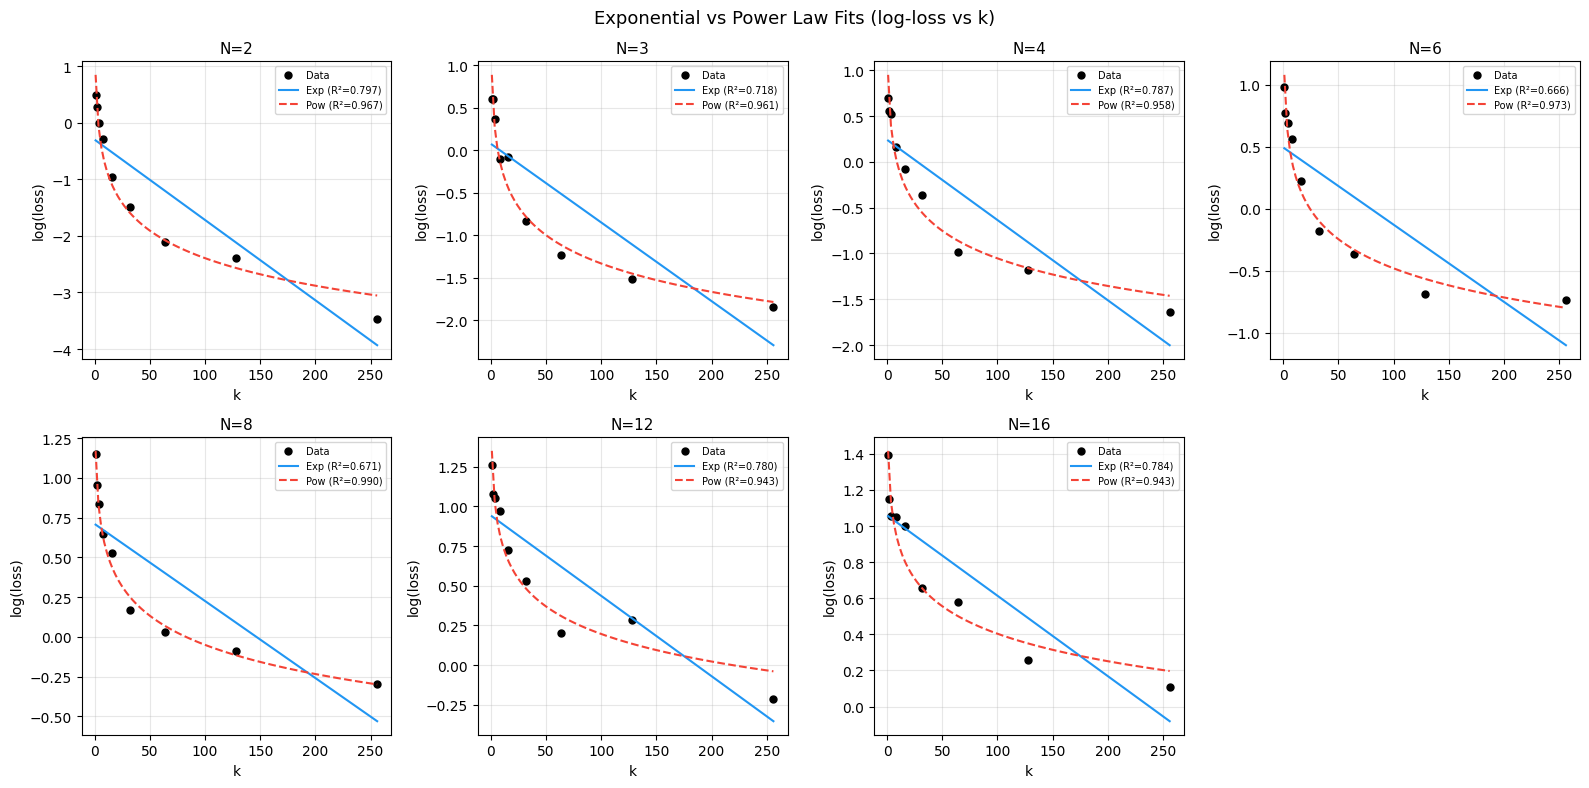


SUMMARY
Exponential (Bayesian) wins: 0/7
Power law wins:              7/7
→ Evidence FAVORS power law over Bayesian


In [95]:
from scipy.stats import linregress

# --- Collect loss curves from difficulty_results ---
loss_curves = {}  # n_classes -> (ks, mean_losses)
for n_classes in sorted(difficulty_results.keys()):
    k_results = difficulty_results[n_classes]
    ks = sorted(k_results.keys())
    mean_losses = [np.mean([r["loss"] for r in k_results[k]]) for k in ks]
    loss_curves[n_classes] = (np.array(ks), np.array(mean_losses))

# =============================================
# Plot 1: log(loss) vs k — Linear = Bayesian
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.cm.viridis
colors_sweep = {n: cmap(i / (len(loss_curves) - 1)) for i, n in enumerate(sorted(loss_curves.keys()))}

ax = axes[0]
for n_classes, (ks, losses) in sorted(loss_curves.items()):
    mask = ks > 0
    ax.plot(ks[mask], np.log(losses[mask]), marker='o', label=f'N={n_classes}',
            color=colors_sweep[n_classes], linewidth=2)

ax.set_xlabel('Number of demonstrations (k)')
ax.set_ylabel('log(loss)')
ax.set_title('log(loss) vs k\n(Linear = Bayesian exponential decay)')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# =============================================
# Plot 2: log(loss) vs log(k) — Linear = Power law
# =============================================
ax = axes[1]
for n_classes, (ks, losses) in sorted(loss_curves.items()):
    mask = ks > 0
    ax.plot(np.log(ks[mask]), np.log(losses[mask]), marker='s', label=f'N={n_classes}',
            color=colors_sweep[n_classes], linewidth=2)

ax.set_xlabel('log(k)')
ax.set_ylabel('log(loss)')
ax.set_title('log(loss) vs log(k)\n(Linear = power law decay)')
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

plt.suptitle('Bayesian vs Power Law Diagnostics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================
# Quantitative: Fit both models, compare R²
# =============================================
print("=" * 70)
print("Model Fit Comparison: Exponential (Bayesian) vs Power Law")
print("=" * 70)
print(f"{'N':>4s}  {'R²(exp)':>10s}  {'R²(power)':>10s}  {'Better':>10s}  {'exp slope':>10s}  {'pow exponent':>12s}")
print("-" * 70)

fit_results = {}
for n_classes, (ks, losses) in sorted(loss_curves.items()):
    mask = ks > 0
    k_pos = ks[mask].astype(float)
    log_loss = np.log(losses[mask])
    log_k = np.log(k_pos)

    # Exponential fit: log(loss) = a - b*k
    slope_exp, intercept_exp, r_exp, _, _ = linregress(k_pos, log_loss)
    r2_exp = r_exp**2

    # Power law fit: log(loss) = a - α*log(k)
    slope_pow, intercept_pow, r_pow, _, _ = linregress(log_k, log_loss)
    r2_pow = r_pow**2

    better = "Exponential" if r2_exp > r2_pow else "Power law"
    print(f"{n_classes:4d}  {r2_exp:10.4f}  {r2_pow:10.4f}  {better:>10s}  {slope_exp:10.5f}  {slope_pow:12.4f}")

    fit_results[n_classes] = {
        'r2_exp': r2_exp, 'r2_pow': r2_pow,
        'slope_exp': slope_exp, 'slope_pow': slope_pow,
        'better': better,
    }

# =============================================
# Plot 3: R² comparison bar chart
# =============================================
fig, ax = plt.subplots(figsize=(8, 5))
n_list = sorted(fit_results.keys())
x = np.arange(len(n_list))
width = 0.35

r2_exps = [fit_results[n]['r2_exp'] for n in n_list]
r2_pows = [fit_results[n]['r2_pow'] for n in n_list]

bars1 = ax.bar(x - width/2, r2_exps, width, label='Exponential (Bayesian)', color='#2196f3', alpha=0.8)
bars2 = ax.bar(x + width/2, r2_pows, width, label='Power law', color='#f44336', alpha=0.8)

ax.set_xlabel('Number of classes (N)')
ax.set_ylabel('R²')
ax.set_title('Model Fit Quality: Exponential vs Power Law')
ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in n_list])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# =============================================
# Plot 4: Transition k vs N (sample complexity)
# =============================================
fig, ax = plt.subplots(figsize=(8, 5))
transition_ks = []
n_list_trans = []

for n_classes in sorted(difficulty_results.keys()):
    k_results = difficulty_results[n_classes]
    ks = sorted(k_results.keys())
    accs = [np.mean([r["accuracy"] for r in k_results[k]]) for k in ks]
    max_acc = max(accs)
    chance = 1.0 / n_classes
    threshold = chance + 0.75 * (max_acc - chance)  # 75% of way from chance to max

    trans_k = ks[-1]  # default: never reached
    for k, acc in zip(ks, accs):
        if acc >= threshold:
            trans_k = k
            break

    transition_ks.append(trans_k)
    n_list_trans.append(n_classes)

ax.plot(n_list_trans, transition_ks, 'o-', color='#2196f3', linewidth=2, markersize=8, label='Observed')

if len(n_list_trans) > 2:
    n_arr = np.array(n_list_trans, dtype=float)
    tk_arr = np.array(transition_ks, dtype=float)

    # Linear fit
    slope_lin, intercept_lin, r_lin, _, _ = linregress(n_arr, tk_arr)
    ax.plot(n_arr, slope_lin * n_arr + intercept_lin, '--', color='#f44336',
            label=f'Linear fit (R²={r_lin**2:.3f})', linewidth=1.5)

    # N*log(N) fit
    nlogn = n_arr * np.log(n_arr)
    slope_nln, intercept_nln, r_nln, _, _ = linregress(nlogn, tk_arr)
    ax.plot(n_arr, slope_nln * nlogn + intercept_nln, ':', color='#4caf50',
            label=f'N·log(N) fit (R²={r_nln**2:.3f})', linewidth=1.5)

ax.set_xlabel('Number of classes (N)')
ax.set_ylabel('Transition k (demos to reach 75% of max)')
ax.set_title('Sample Complexity Scaling\n(Bayesian prediction: linear in N)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================
# Plot 5: Per-N fit overlays
# =============================================
n_panels = len(difficulty_results)
ncols = 4
nrows = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for idx, n_classes in enumerate(sorted(difficulty_results.keys())):
    ax = axes[idx]
    ks, losses = loss_curves[n_classes]
    mask = ks > 0
    k_pos = ks[mask].astype(float)
    log_loss = np.log(losses[mask])

    ax.plot(k_pos, log_loss, 'ko', markersize=5, label='Data')

    # Exponential fit
    s_e, i_e, _, _, _ = linregress(k_pos, log_loss)
    k_fit = np.linspace(k_pos.min(), k_pos.max(), 100)
    ax.plot(k_fit, s_e * k_fit + i_e, '-', color='#2196f3', linewidth=1.5,
            label=f'Exp (R²={fit_results[n_classes]["r2_exp"]:.3f})')

    # Power law fit (in linear-k space)
    s_p, i_p, _, _, _ = linregress(np.log(k_pos), log_loss)
    ax.plot(k_fit, s_p * np.log(k_fit) + i_p, '--', color='#f44336', linewidth=1.5,
            label=f'Pow (R²={fit_results[n_classes]["r2_pow"]:.3f})')

    ax.set_title(f'N={n_classes}', fontsize=11)
    ax.set_xlabel('k')
    ax.set_ylabel('log(loss)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for idx in range(len(difficulty_results), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Exponential vs Power Law Fits (log-loss vs k)', fontsize=13)
plt.tight_layout()
plt.show()

# =============================================
# Summary
# =============================================
n_exp_wins = sum(1 for v in fit_results.values() if v['better'] == 'Exponential')
n_pow_wins = sum(1 for v in fit_results.values() if v['better'] == 'Power law')
print(f"\n{'='*50}")
print(f"SUMMARY")
print(f"{'='*50}")
print(f"Exponential (Bayesian) wins: {n_exp_wins}/{len(fit_results)}")
print(f"Power law wins:              {n_pow_wins}/{len(fit_results)}")
if n_exp_wins > n_pow_wins:
    print("→ Evidence SUPPORTS Bayesian interpretation of ICL")
elif n_pow_wins > n_exp_wins:
    print("→ Evidence FAVORS power law over Bayesian")
else:
    print("→ Mixed evidence — neither model clearly dominates")

## Task 4: Function Induction

Instead of learning a threshold (boundary in 1D), the model must learn a **function** mapping integers to classes.

| Function type | Rule | Parameters | Why harder? |
|--------------|------|-----------|------------|
| **Linear** | f(x) = (ax + b) mod M | 2 (a, b) | Regular pattern, periodic in input |
| **Quadratic** | f(x) = (ax² + bx + c) mod M | 3 (a, b, c) | Non-monotonic, more complex pattern |
| **Periodic** | f(x) = (a·(x mod p) + b) mod M | 3 (a, b, period) | Hidden period must be inferred |

M (number of output classes) controls difficulty, like N did for thresholds.

**Key difference from thresholds**: threshold tasks have spatially contiguous classes (all numbers below t are class A). Function induction tasks have **interleaved** class assignments — nearby numbers can map to different classes. This requires learning the actual function, not just a decision boundary.

In [96]:
class FunctionInductionTask:
    """Function induction task family.

    The model sees (x, f(x)) pairs and must predict f(x_test) for a novel x_test.

    Function types:
    - "linear": f(x) = (ax + b) mod M
    - "quadratic": f(x) = (ax² + bx + c) mod M
    - "periodic": f(x) = (a*(x mod p) + b) mod M  (hidden period p)

    Difficulty controlled by n_outputs (M) and function type.
    """

    def __init__(self, func_type="linear", n_outputs=5, num_range=1000, seed=None):
        self.func_type = func_type
        self.n_outputs = n_outputs
        self.num_range = num_range
        self.labels = CLASS_LABELS[:n_outputs]
        self.rng = np.random.RandomState(seed)

    def _sample_function(self):
        M = self.n_outputs
        if self.func_type == "linear":
            a = self.rng.randint(1, 20)
            b = self.rng.randint(0, M)
            return lambda x, _a=a, _b=b, _M=M: (_a * x + _b) % _M
        elif self.func_type == "quadratic":
            a = self.rng.randint(1, 10)
            b = self.rng.randint(0, 20)
            c = self.rng.randint(0, M)
            return lambda x, _a=a, _b=b, _c=c, _M=M: (_a * x**2 + _b * x + _c) % _M
        elif self.func_type == "periodic":
            period = self.rng.randint(3, 15)
            a = self.rng.randint(1, 10)
            b = self.rng.randint(0, M)
            return lambda x, _a=a, _b=b, _p=period, _M=M: (_a * (x % _p) + _b) % _M
        else:
            raise ValueError(f"Unknown func_type: {self.func_type}")

    def sample_task(self, n_demos, n_test=1):
        f = self._sample_function()
        n_total = n_demos + n_test
        xs = self.rng.choice(self.num_range, size=n_total, replace=False).tolist()
        pairs = [(str(x), self.labels[f(x)]) for x in xs]
        return pairs[:n_demos], pairs[n_demos:]

    def sample_distractor_task(self, n_demos):
        f = self._sample_function()
        xs = self.rng.choice(self.num_range, size=n_demos, replace=False).tolist()
        return [(str(x), self.labels[f(x)]) for x in xs]


# Quick test: show example prompts for each function type
for ft in ["linear", "quadratic", "periodic"]:
    task = FunctionInductionTask(func_type=ft, n_outputs=5, seed=42)
    demos, tests = task.sample_task(n_demos=6, n_test=1)
    print(f"=== {ft} (M=5) ===")
    print(format_demos(demos, tests[0][0]))
    print(f"Expected: {tests[0][1]}\n")

=== linear (M=5) ===
521 -> A
739 -> B
823 -> E
662 -> C
411 -> A
680 -> D
628 ->
Expected: E

=== quadratic (M=5) ===
626 -> A
629 -> C
847 -> A
514 -> C
365 -> E
903 -> E
655 ->
Expected: E

=== periodic (M=5) ===
626 -> E
629 -> B
847 -> D
514 -> D
365 -> E
903 -> B
655 ->
Expected: C



In [97]:
# Function induction sweep: 3 function types × 3 M values
FUNC_TYPES = ["linear", "quadratic", "periodic"]
FUNC_M_VALUES = [3, 5, 8]
FUNC_K_VALUES = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
FUNC_N_TRIALS = 50

func_results = load_results("func_results")
if func_results is None:
    func_results = {}  # (func_type, M) -> {k -> [results]}

    for func_type in tqdm(FUNC_TYPES, desc="Function types"):
        for M in tqdm(FUNC_M_VALUES, desc=f"{func_type}", leave=False):
            task_gen = FunctionInductionTask(func_type=func_type, n_outputs=M,
                                             seed=300 + hash(func_type) % 100 + M)
            k_results = defaultdict(list)

            for k in tqdm(FUNC_K_VALUES, desc=f"{func_type}/M={M}", leave=False):
                for trial in range(FUNC_N_TRIALS):
                    demos, tests = task_gen.sample_task(n_demos=k, n_test=1)
                    test_word, test_label = tests[0]
                    prompt = format_demos(demos, test_word)
                    target = f" {test_label}"
                    result = evaluate_prompt(model, tokenizer, prompt, target, device)
                    result["k"] = k
                    k_results[k].append(result)

            func_results[(func_type, M)] = dict(k_results)

    save_results("func_results", func_results)
    print("Function induction sweep complete.")

Function types:   0%|          | 0/3 [00:00<?, ?it/s]

linear:   0%|          | 0/3 [00:00<?, ?it/s]

linear/M=3:   0%|          | 0/10 [00:00<?, ?it/s]

linear/M=5:   0%|          | 0/10 [00:00<?, ?it/s]

linear/M=8:   0%|          | 0/10 [00:00<?, ?it/s]

...

periodic:   0%|          | 0/3 [00:00<?, ?it/s]

periodic/M=3:   0%|          | 0/10 [00:00<?, ?it/s]

periodic/M=5:   0%|          | 0/10 [00:00<?, ?it/s]

periodic/M=8:   0%|          | 0/10 [00:00<?, ?it/s]

  [cache] Saved func_results
Function induction sweep complete.


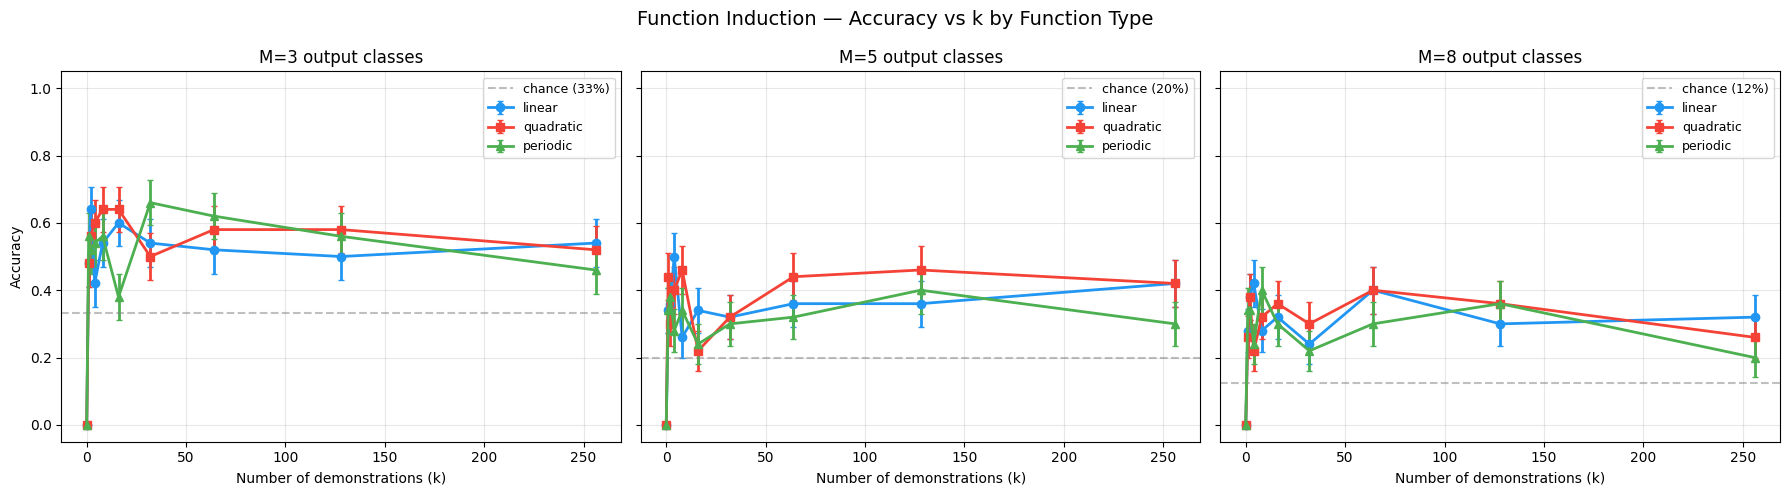

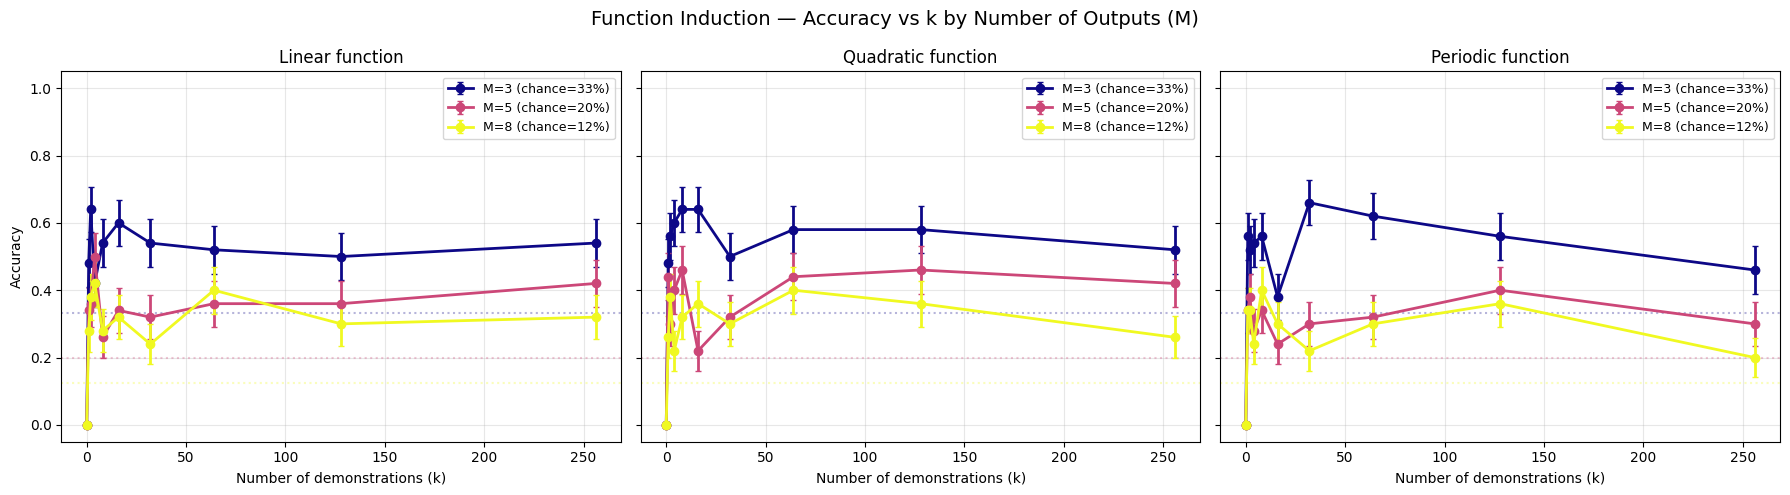

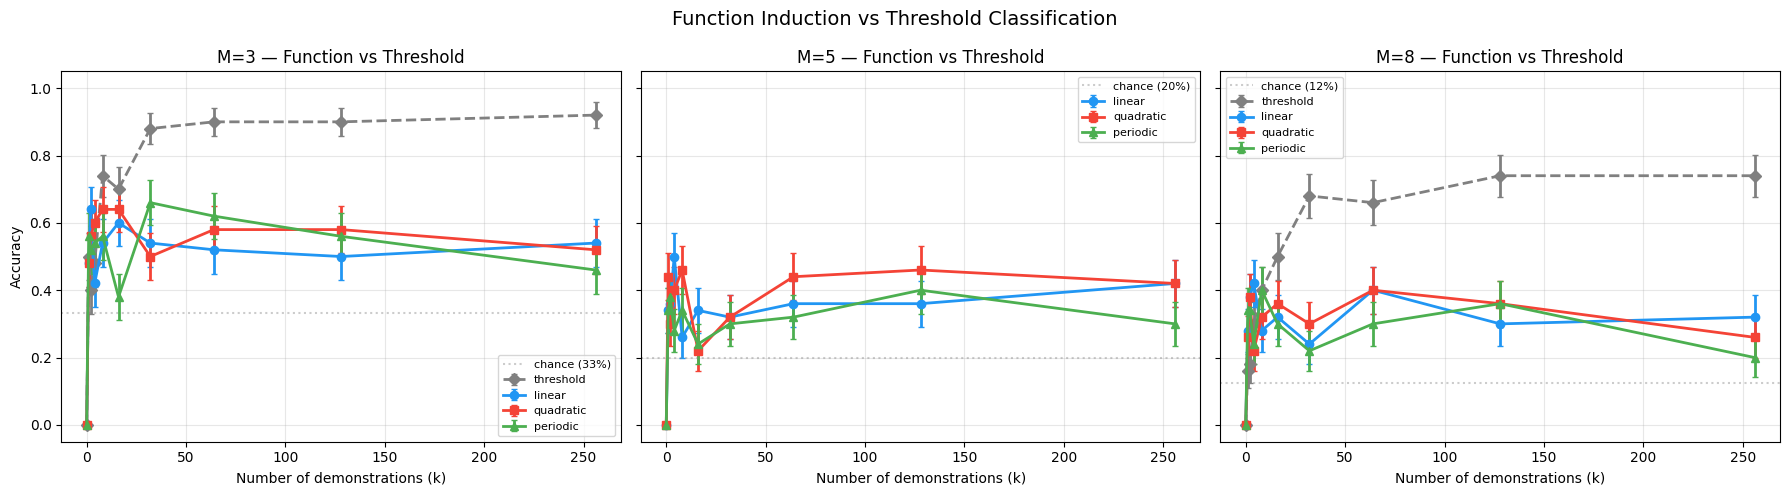


Accuracy at k=256 by function type and M:
   func_type  M= 3  M= 5  M= 8
------------------------------
      linear   54% (1.6x)   42% (2.1x)   32% (2.6x)
   quadratic   52% (1.6x)   42% (2.1x)   26% (2.1x)
    periodic   46% (1.4x)   30% (1.5x)   20% (1.6x)
   threshold   92% (2.8x)         N/A   74% (5.9x)


In [98]:
# === Plot 1: Learning curves by function type (one panel per M) ===
func_colors = {"linear": "#2196f3", "quadratic": "#f44336", "periodic": "#4caf50"}
func_markers = {"linear": "o", "quadratic": "s", "periodic": "^"}

fig, axes = plt.subplots(1, len(FUNC_M_VALUES), figsize=(6 * len(FUNC_M_VALUES), 5), sharey=True)

for idx, M in enumerate(FUNC_M_VALUES):
    ax = axes[idx]
    chance = 1.0 / M

    for func_type in FUNC_TYPES:
        k_results = func_results[(func_type, M)]
        ks = sorted(k_results.keys())
        means = [np.mean([r["accuracy"] for r in k_results[k]]) for k in ks]
        sems = [np.std([r["accuracy"] for r in k_results[k]]) / np.sqrt(len(k_results[k])) for k in ks]

        ax.errorbar(ks, means, yerr=sems, label=func_type,
                    color=func_colors[func_type], marker=func_markers[func_type],
                    capsize=2, linewidth=2)

    ax.axhline(y=chance, color="gray", linestyle="--", alpha=0.5, label=f"chance ({chance:.0%})")
    ax.set_xlabel("Number of demonstrations (k)")
    ax.set_title(f"M={M} output classes")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    if idx == 0:
        ax.set_ylabel("Accuracy")

plt.suptitle("Function Induction — Accuracy vs k by Function Type", fontsize=14)
plt.tight_layout()
plt.show()

# === Plot 2: Learning curves by M (one panel per function type) ===
cmap_m = plt.cm.plasma
m_colors = {m: cmap_m(i / (len(FUNC_M_VALUES) - 1)) for i, m in enumerate(FUNC_M_VALUES)}

fig, axes = plt.subplots(1, len(FUNC_TYPES), figsize=(6 * len(FUNC_TYPES), 5), sharey=True)

for idx, func_type in enumerate(FUNC_TYPES):
    ax = axes[idx]

    for M in FUNC_M_VALUES:
        chance = 1.0 / M
        k_results = func_results[(func_type, M)]
        ks = sorted(k_results.keys())
        means = [np.mean([r["accuracy"] for r in k_results[k]]) for k in ks]
        sems = [np.std([r["accuracy"] for r in k_results[k]]) / np.sqrt(len(k_results[k])) for k in ks]

        ax.errorbar(ks, means, yerr=sems, label=f"M={M} (chance={chance:.0%})",
                    color=m_colors[M], marker="o", capsize=2, linewidth=2)
        ax.axhline(y=chance, color=m_colors[M], linestyle=":", alpha=0.3)

    ax.set_xlabel("Number of demonstrations (k)")
    ax.set_title(f"{func_type.capitalize()} function")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    if idx == 0:
        ax.set_ylabel("Accuracy")

plt.suptitle("Function Induction — Accuracy vs k by Number of Outputs (M)", fontsize=14)
plt.tight_layout()
plt.show()

# === Plot 3: Comparison with threshold task at same M ===
# Overlay function induction vs threshold classification at M=3, 5, 8
fig, axes = plt.subplots(1, len(FUNC_M_VALUES), figsize=(6 * len(FUNC_M_VALUES), 5), sharey=True)

for idx, M in enumerate(FUNC_M_VALUES):
    ax = axes[idx]
    chance = 1.0 / M

    # Threshold baseline (from difficulty_results if M matches)
    if M in difficulty_results:
        k_results = difficulty_results[M]
        ks = sorted(k_results.keys())
        means = [np.mean([r["accuracy"] for r in k_results[k]]) for k in ks]
        sems = [np.std([r["accuracy"] for r in k_results[k]]) / np.sqrt(len(k_results[k])) for k in ks]
        ax.errorbar(ks, means, yerr=sems, label="threshold",
                    color="gray", marker="D", capsize=2, linewidth=2, linestyle="--")

    # Function types
    for func_type in FUNC_TYPES:
        k_results = func_results[(func_type, M)]
        ks = sorted(k_results.keys())
        means = [np.mean([r["accuracy"] for r in k_results[k]]) for k in ks]
        sems = [np.std([r["accuracy"] for r in k_results[k]]) / np.sqrt(len(k_results[k])) for k in ks]
        ax.errorbar(ks, means, yerr=sems, label=func_type,
                    color=func_colors[func_type], marker=func_markers[func_type],
                    capsize=2, linewidth=2)

    ax.axhline(y=chance, color="gray", linestyle=":", alpha=0.4, label=f"chance ({chance:.0%})")
    ax.set_xlabel("Number of demonstrations (k)")
    ax.set_title(f"M={M} — Function vs Threshold")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    if idx == 0:
        ax.set_ylabel("Accuracy")

plt.suptitle("Function Induction vs Threshold Classification", fontsize=14)
plt.tight_layout()
plt.show()

# === Summary table ===
print("\nAccuracy at k=256 by function type and M:")
header = f"{'func_type':>12s}" + "".join(f"  M={M:>2d}" for M in FUNC_M_VALUES)
print(header)
print("-" * len(header))
for func_type in FUNC_TYPES:
    row = f"{func_type:>12s}"
    for M in FUNC_M_VALUES:
        k_results = func_results[(func_type, M)]
        max_k = max(k_results.keys())
        acc = np.mean([r["accuracy"] for r in k_results[max_k]])
        chance = 1.0 / M
        row += f"  {acc:>4.0%} ({acc/chance:.1f}x)"
    print(row)

# Threshold comparison
if any(M in difficulty_results for M in FUNC_M_VALUES):
    row = f"{'threshold':>12s}"
    for M in FUNC_M_VALUES:
        if M in difficulty_results:
            max_k = max(difficulty_results[M].keys())
            acc = np.mean([r["accuracy"] for r in difficulty_results[M][max_k]])
            chance = 1.0 / M
            row += f"  {acc:>4.0%} ({acc/chance:.1f}x)"
        else:
            row += f"  {'N/A':>10s}"
    print(row)

## Task 5: Factual Override (ICL vs Prior Knowledge)

Tests whether ICL can **override the model's pretraining knowledge**.

The model knows "France → Paris". We show k demos with systematically shifted facts
(France → Berlin, Germany → Tokyo, ...) and test whether the model follows the demos or its priors.

**Conditions:**
- **Congruent**: demos show correct facts (ICL agrees with priors)
- **Override**: demos show shifted facts (ICL fights priors)
- **Zero-shot**: no demos (pure prior baseline)

**Key prediction**: Override rate should increase from 0% (prior dominates at k=0) toward
100% as k grows — the crossover point measures how strongly ICL can fight pretraining.

In [99]:
class FactualOverrideTask:
    """Tests ICL's ability to override pretraining knowledge.

    Uses country→capital pairs. In the 'override' condition, all answers are
    shifted by 1 position (France→Berlin, Germany→Tokyo, Japan→Rome, ...),
    creating a consistent but factually wrong pattern for the model to follow.
    """

    # (country, correct_capital) — chosen for well-known, short capitals
    FACTS = [
        ("France", "Paris"),
        ("Japan", "Tokyo"),
        ("Italy", "Rome"),
        ("Germany", "Berlin"),
        ("Spain", "Madrid"),
        ("Egypt", "Cairo"),
        ("Canada", "Ottawa"),
        ("India", "Delhi"),
        ("China", "Beijing"),
        ("Russia", "Moscow"),
        ("Turkey", "Ankara"),
        ("Greece", "Athens"),
        ("Peru", "Lima"),
        ("Norway", "Oslo"),
        ("Poland", "Warsaw"),
        ("Sweden", "Stockholm"),
        ("Cuba", "Havana"),
        ("Chile", "Santiago"),
    ]

    def __init__(self, seed=None):
        self.rng = np.random.RandomState(seed)

    def _build_prompt(self, demos, test_country):
        """Build 'Country → Capital' format prompt."""
        lines = [f"{country} → {capital}" for country, capital in demos]
        lines.append(f"{test_country} →")
        return "\n".join(lines)

    def _get_shifted_facts(self, facts):
        """Shift all capitals by 1 position: France→Berlin, Germany→Tokyo, etc."""
        countries = [f[0] for f in facts]
        capitals = [f[1] for f in facts]
        shifted_capitals = [capitals[-1]] + capitals[:-1]  # rotate right by 1
        return list(zip(countries, shifted_capitals))

    def sample_trial(self, k, condition="congruent"):
        """Sample a single trial.

        Returns: (prompt, correct_target, prior_target, condition)
        - correct_target: answer consistent with demos
        - prior_target: answer the model would give from pretraining
        """
        # Shuffle and split into demos + test
        indices = self.rng.permutation(len(self.FACTS)).tolist()
        demo_indices = indices[:k]
        test_idx = indices[k] if k < len(self.FACTS) else indices[0]

        correct_facts = [self.FACTS[i] for i in demo_indices]
        test_country, test_prior_capital = self.FACTS[test_idx]

        if condition == "congruent":
            demos = correct_facts
            target = f" {test_prior_capital}"
            prior = f" {test_prior_capital}"
        elif condition == "override":
            all_selected = [self.FACTS[i] for i in demo_indices + [test_idx]]
            shifted = self._get_shifted_facts(all_selected)
            demos = shifted[:k]
            # The "correct" answer from the shifted pattern
            target = f" {shifted[k][1]}"
            prior = f" {test_prior_capital}"
        elif condition == "zero_shot":
            demos = []
            target = f" {test_prior_capital}"
            prior = f" {test_prior_capital}"
        else:
            raise ValueError(f"Unknown condition: {condition}")

        prompt = self._build_prompt(demos, test_country)
        return prompt, target, prior


# Quick test
task = FactualOverrideTask(seed=42)

print("=== Congruent (correct facts) ===")
prompt, target, prior = task.sample_trial(k=4, condition="congruent")
print(prompt)
print(f"Target (from demos): {target}, Prior: {prior}\n")

print("=== Override (shifted facts) ===")
prompt, target, prior = task.sample_trial(k=4, condition="override")
print(prompt)
print(f"Target (from demos): {target}, Prior (pretraining): {prior}")

=== Congruent (correct facts) ===
France → Paris
Japan → Tokyo
China → Beijing
Egypt → Cairo
Germany →
Target (from demos):  Berlin, Prior:  Berlin

=== Override (shifted facts) ===
Sweden → Beijing
India → Stockholm
Canada → Delhi
Italy → Ottawa
China →
Target (from demos):  Rome, Prior (pretraining):  Beijing


Factual [congruent]:   0%|          | 0/9 [00:00<?, ?it/s]

Factual [override]:   0%|          | 0/9 [00:00<?, ?it/s]

  [cache] Saved factual_results


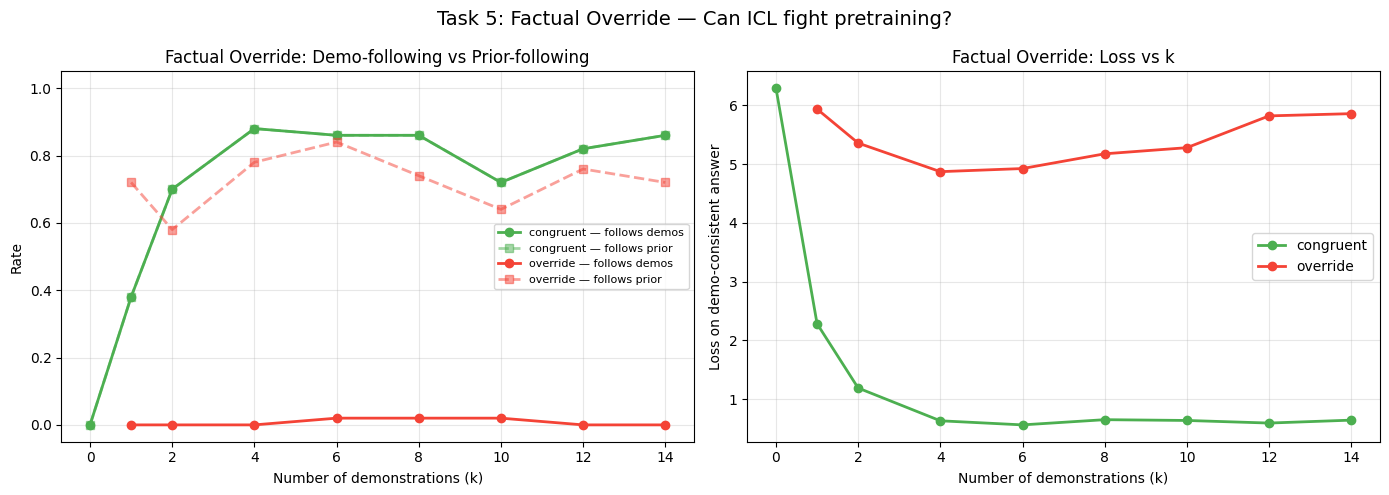


Factual Override summary:
   congruent k= 0: demos=0%, prior=0%
   congruent k= 1: demos=38%, prior=38%
   congruent k= 2: demos=70%, prior=70%
   congruent k= 4: demos=88%, prior=88%
   congruent k= 6: demos=86%, prior=86%
   congruent k= 8: demos=86%, prior=86%
   congruent k=10: demos=72%, prior=72%
   congruent k=12: demos=82%, prior=82%
   congruent k=14: demos=86%, prior=86%
    override k= 1: demos=0%, prior=72%
    override k= 2: demos=0%, prior=58%
    override k= 4: demos=0%, prior=78%
    override k= 6: demos=2%, prior=84%
    override k= 8: demos=2%, prior=74%
    override k=10: demos=2%, prior=64%
    override k=12: demos=0%, prior=76%
    override k=14: demos=0%, prior=72%


In [100]:
# Factual override experiment
FACTUAL_K_VALUES = [0, 1, 2, 4, 6, 8, 10, 12, 14]  # max ~14 (18 facts, need holdout)
FACTUAL_N_TRIALS = 50
FACTUAL_CONDITIONS = ["congruent", "override"]

factual_results = load_results("factual_results")
if factual_results is None:
    factual_results = defaultdict(lambda: defaultdict(list))

    for condition in FACTUAL_CONDITIONS:
        for k in tqdm(FACTUAL_K_VALUES, desc=f"Factual [{condition}]"):
            if k == 0 and condition == "override":
                continue  # override with 0 demos is meaningless
            for trial in range(FACTUAL_N_TRIALS):
                task = FactualOverrideTask(seed=500 + trial)
                prompt, target, prior = task.sample_trial(k=max(k, 1) if condition != "override" else k,
                                                           condition=condition if k > 0 else "zero_shot")

                # Evaluate against demo-consistent target
                res_target = evaluate_prompt(model, tokenizer, prompt, target, device)

                # Also check what the model actually generates
                generated = res_target["generated"].strip()

                # Score: did model follow demos or priors?
                followed_demos = 1.0 if generated.lower().startswith(target.strip().lower()) else 0.0
                followed_prior = 1.0 if generated.lower().startswith(prior.strip().lower()) else 0.0

                factual_results[condition][k].append({
                    "accuracy": res_target["accuracy"],  # exact match with demo target
                    "loss": res_target["loss"],
                    "generated": generated,
                    "target": target.strip(),
                    "prior": prior.strip(),
                    "followed_demos": followed_demos,
                    "followed_prior": followed_prior,
                    "k": k,
                })

    factual_results = dict(factual_results)
    save_results("factual_results", factual_results)

# Plot 1: Demo-following rate vs k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cond_colors = {"congruent": "#4caf50", "override": "#f44336"}
for condition in FACTUAL_CONDITIONS:
    k_results = factual_results[condition]
    ks = sorted(k_results.keys())
    demo_rates = [np.mean([r["followed_demos"] for r in k_results[k]]) for k in ks]
    prior_rates = [np.mean([r["followed_prior"] for r in k_results[k]]) for k in ks]

    ax.plot(ks, demo_rates, marker="o", linewidth=2, color=cond_colors[condition],
            label=f"{condition} — follows demos")
    ax.plot(ks, prior_rates, marker="s", linewidth=2, color=cond_colors[condition],
            linestyle="--", alpha=0.5, label=f"{condition} — follows prior")

ax.set_xlabel("Number of demonstrations (k)")
ax.set_ylabel("Rate")
ax.set_title("Factual Override: Demo-following vs Prior-following")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)

# Plot 2: Loss on demo-consistent answer
ax = axes[1]
for condition in FACTUAL_CONDITIONS:
    k_results = factual_results[condition]
    ks = sorted(k_results.keys())
    losses = [np.mean([r["loss"] for r in k_results[k]]) for k in ks]

    ax.plot(ks, losses, marker="o", linewidth=2, color=cond_colors[condition],
            label=condition)

ax.set_xlabel("Number of demonstrations (k)")
ax.set_ylabel("Loss on demo-consistent answer")
ax.set_title("Factual Override: Loss vs k")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Task 5: Factual Override — Can ICL fight pretraining?", fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("\nFactual Override summary:")
for condition in FACTUAL_CONDITIONS:
    k_results = factual_results[condition]
    ks = sorted(k_results.keys())
    for k in ks:
        demo_rate = np.mean([r["followed_demos"] for r in k_results[k]])
        prior_rate = np.mean([r["followed_prior"] for r in k_results[k]])
        print(f"  {condition:>10s} k={k:2d}: demos={demo_rate:.0%}, prior={prior_rate:.0%}")

## Task 6: Emotion Elicitation

Tests how many Q&A demos it takes to **elicit a particular emotional tone** in the model's responses.

We show k Q&A pairs where responses consistently express a target emotion (enthusiastic, angry,
or melancholic), then ask a new question and measure whether the model responds in that emotion.

**Two evaluation metrics:**
1. **Keyword scoring**: count emotion-specific words in the generated response
2. **Loss probing**: compute loss on short emotion-specific phrases — the emotion with lowest loss is the model's "natural continuation"

**Two test conditions:**
- **Related**: test question is about everyday topics (same domain as demos)
- **Unrelated**: test question is about something completely different (e.g., math, science)

In [101]:
class EmotionElicitationTask:
    """Tests how many Q&A demos to elicit a target emotion.

    Shows k Q&A pairs in a consistent emotional tone, then asks a new question.
    Evaluates via keyword scoring and loss probing.
    """

    # Q&A pool: question + response per emotion
    # Each entry: (question, {emotion: response})
    QA_POOL = [
        ("What do you think about rainy days?", {
            "enthusiastic": "Oh, rainy days are absolutely wonderful! I love the soothing sound of raindrops and the cozy feeling they bring! Everything feels so refreshing and alive!",
            "angry": "Rainy days are the worst! I absolutely hate getting soaked and dealing with the miserable grey skies. It ruins everything and makes the whole day terrible!",
            "melancholic": "Rainy days carry a certain sadness with them. The grey skies remind me of things lost, and there's a deep loneliness in watching the drops fall endlessly.",
        }),
        ("How do you feel about Monday mornings?", {
            "enthusiastic": "Monday mornings are fantastic! A brand new week full of incredible possibilities! I can barely contain my excitement for all the amazing things ahead!",
            "angry": "Monday mornings are absolutely dreadful! Another miserable week of pointless obligations. I despise how they rip away any sense of freedom!",
            "melancholic": "Monday mornings feel heavy somehow. Another week begins and I wonder where all the time has gone. There's a quiet ache in starting over again.",
        }),
        ("What's your opinion on cooking at home?", {
            "enthusiastic": "Cooking at home is incredible! I absolutely love creating delicious meals and the kitchen fills with the most amazing aromas! It brings such joy!",
            "angry": "Cooking at home is such a frustrating waste of time! The mess, the effort, the dishes — it's infuriating how much work it takes for one stupid meal!",
            "melancholic": "There's something bittersweet about cooking alone at home. The empty chair at the table, the silence — it reminds me of meals once shared with others.",
        }),
        ("What do you think about social media?", {
            "enthusiastic": "Social media is amazing! I love connecting with friends and discovering incredible new ideas! It's wonderful how it brings the whole world together!",
            "angry": "Social media is a toxic wasteland! I hate how it manipulates people and spreads hateful nonsense. It's destroying real human connection and it's disgusting!",
            "melancholic": "Social media makes me feel strangely empty. Scrolling through everyone's highlights while sitting alone — there's a quiet sadness in all that artificial connection.",
        }),
        ("How do you feel about exercise?", {
            "enthusiastic": "Exercise is absolutely exhilarating! I love the rush of energy and how incredible my body feels afterwards! Every workout is a celebration of being alive!",
            "angry": "Exercise is such a painful chore! I hate the soreness and the exhausting effort. It's ridiculous that we're expected to torture ourselves like this!",
            "melancholic": "Exercise sometimes feels like going through the motions. The body moves but the mind wanders to places tinged with regret and quiet longing.",
        }),
        ("What's your take on winter?", {
            "enthusiastic": "Winter is magical! I absolutely adore the sparkling snow and cozy evenings! There's nothing more wonderful than a beautiful winter wonderland!",
            "angry": "Winter is absolutely unbearable! The freezing cold, the dangerous ice, the endless darkness — I hate every miserable second of it!",
            "melancholic": "Winter has a melancholy beauty. The bare trees and early darkness mirror something inside — a quiet sadness that settles in like the cold.",
        }),
        ("What do you think about travelling?", {
            "enthusiastic": "Travelling is the most exciting thing ever! I love exploring new places, meeting amazing people, and every trip is an incredible adventure!",
            "angry": "Travelling is an overrated nightmare! Delays, lost luggage, terrible crowds — I hate the stress and the ridiculous expense of it all!",
            "melancholic": "Travelling reminds me that no matter how far I go, I carry the same sadness. New places are beautiful but there's an ache in being far from home.",
        }),
        ("How do you feel about music?", {
            "enthusiastic": "Music is absolutely breathtaking! I love how a song can make your heart soar! Every melody is a gift and I'm thrilled by all the incredible artists!",
            "angry": "Don't get me started on how terrible most music is today! It's infuriating how awful and repetitive everything sounds. The industry is a complete disgrace!",
            "melancholic": "Music stirs something deep and sorrowful in me. Certain melodies bring tears I didn't know I was holding. There's beauty in that sadness, I suppose.",
        }),
        ("What's your opinion on pets?", {
            "enthusiastic": "Pets are the most wonderful companions! I absolutely love them! Dogs, cats — they bring so much joy and unconditional love into our lives!",
            "angry": "Pets are such an annoying responsibility! The mess, the noise, the vet bills — I'm furious at how much trouble they cause for so little in return!",
            "melancholic": "Pets remind us that love always comes with loss. Their short lives are a bittersweet gift — so much warmth, shadowed by the knowledge they'll leave too soon.",
        }),
        ("How do you feel about reading books?", {
            "enthusiastic": "Reading is absolutely wonderful! I love getting lost in amazing stories! Every book is a thrilling new world to explore and I can't get enough!",
            "angry": "Most books are a complete waste of time! I hate how boring and pretentious so many authors are. It's outrageous how much garbage gets published!",
            "melancholic": "Books are a refuge for the lonely heart. I lose myself in stories to forget the ache of reality, finding comfort in words that understand my sorrow.",
        }),
        ("What do you think about coffee?", {
            "enthusiastic": "Coffee is absolutely divine! I love everything about it — the rich aroma, the wonderful taste! Every cup is a little moment of pure bliss!",
            "angry": "Coffee is overpriced bitter garbage! I hate how everyone treats it like a personality trait. The whole coffee culture is insufferably annoying!",
            "melancholic": "There's something lonely about a cup of coffee. The warmth fades so quickly, like so many things. I sit and drink and think of mornings that used to be different.",
        }),
        ("How do you feel about weekends?", {
            "enthusiastic": "Weekends are incredible! I love having time for all the amazing things I enjoy! Every Saturday feels like a wonderful gift full of possibilities!",
            "angry": "Weekends are never long enough and that's infuriating! Two measly days? I hate how they fly by before you can even catch your breath!",
            "melancholic": "Weekends can be the loneliest times. While everyone seems to be somewhere with someone, the quiet hours stretch out, heavy with things unsaid.",
        }),
    ]

    # Unrelated test questions (different domain from everyday opinions)
    UNRELATED_QUESTIONS = [
        "Can you explain what photosynthesis is?",
        "What happens when you mix baking soda and vinegar?",
        "How does a compass work?",
        "What are the planets in our solar system?",
        "Why is the sky blue?",
    ]

    # Emotion-specific keywords for scoring generated text
    EMOTION_KEYWORDS = {
        "enthusiastic": ["wonderful", "amazing", "love", "fantastic", "incredible", "exciting",
                         "beautiful", "thrilling", "joy", "delightful", "exhilarating", "adore",
                         "magnificent", "brilliant", "superb", "!"],
        "angry": ["terrible", "awful", "hate", "ridiculous", "unacceptable", "furious",
                  "outrageous", "disgusting", "infuriating", "worst", "despise", "dreadful",
                  "miserable", "annoying", "stupid", "nightmare"],
        "melancholic": ["sad", "lonely", "sorrow", "melancholy", "bittersweet", "ache",
                        "longing", "regret", "empty", "loss", "tears", "wistful",
                        "quiet", "heavy", "fading", "forgotten"],
    }

    # Short probe phrases for loss-based evaluation
    EMOTION_PROBES = {
        "enthusiastic": " That's absolutely wonderful! I love",
        "angry": " That's absolutely terrible! I hate",
        "melancholic": " That's rather sad, unfortunately. I",
    }

    EMOTIONS = ["enthusiastic", "angry", "melancholic"]

    def __init__(self, seed=None):
        self.rng = np.random.RandomState(seed)

    def sample_trial(self, k, target_emotion, test_type="related"):
        """Sample a trial with k demos in target_emotion.

        Returns: (prompt, target_emotion, test_question)
        """
        indices = self.rng.permutation(len(self.QA_POOL)).tolist()
        demo_indices = indices[:k]

        # Build demos
        demos_text = []
        for i in demo_indices:
            q, responses = self.QA_POOL[i]
            demos_text.append(f"Q: {q}\nA: {responses[target_emotion]}")

        # Test question
        if test_type == "related":
            # Pick a question not used in demos
            remaining = [i for i in indices[k:] if i < len(self.QA_POOL)]
            test_idx = remaining[0] if remaining else indices[0]
            test_q = self.QA_POOL[test_idx][0]
        else:  # unrelated
            test_q = self.UNRELATED_QUESTIONS[self.rng.randint(0, len(self.UNRELATED_QUESTIONS))]

        # Build prompt
        prompt = "\n\n".join(demos_text)
        if demos_text:
            prompt += f"\n\nQ: {test_q}\nA:"
        else:
            prompt = f"Q: {test_q}\nA:"

        return prompt, target_emotion, test_q

    def score_keywords(self, text, emotion):
        """Score text for emotion-specific keywords. Returns count."""
        text_lower = text.lower()
        return sum(1 for kw in self.EMOTION_KEYWORDS[emotion] if kw in text_lower)

    def classify_by_keywords(self, text):
        """Classify text by emotion using keyword counts."""
        scores = {e: self.score_keywords(text, e) for e in self.EMOTIONS}
        if max(scores.values()) == 0:
            return "neutral"
        return max(scores, key=scores.get)


@torch.no_grad()
def evaluate_emotion(model, tokenizer, prompt, task, device, max_new_tokens=60):
    """Evaluate emotion elicitation: generate text + compute probe losses."""
    prompt_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    # Generate free-form response
    generated_ids = model.generate(
        prompt_ids,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    generated_text = tokenizer.decode(generated_ids[0, prompt_ids.shape[1]:], skip_special_tokens=True)

    # Keyword classification
    keyword_emotion = task.classify_by_keywords(generated_text)
    keyword_scores = {e: task.score_keywords(generated_text, e) for e in task.EMOTIONS}

    # Loss probing: compute loss on each emotion's probe phrase
    probe_losses = {}
    for emotion, probe in task.EMOTION_PROBES.items():
        probe_ids = tokenizer.encode(probe, add_special_tokens=False, return_tensors="pt").to(device)
        full_ids = torch.cat([prompt_ids, probe_ids], dim=1)
        outputs = model(full_ids)
        logits = outputs.logits
        prompt_len = prompt_ids.shape[1]
        probe_len = probe_ids.shape[1]
        probe_logits = logits[0, prompt_len - 1 : prompt_len + probe_len - 1, :]
        loss = torch.nn.functional.cross_entropy(probe_logits.float(), probe_ids[0]).item()
        probe_losses[emotion] = loss

    probe_emotion = min(probe_losses, key=probe_losses.get)

    return {
        "generated": generated_text,
        "keyword_emotion": keyword_emotion,
        "keyword_scores": keyword_scores,
        "probe_losses": probe_losses,
        "probe_emotion": probe_emotion,
    }


# Quick test
task = EmotionElicitationTask(seed=42)
print("=== Enthusiastic demo (k=2) + related test ===")
prompt, target_em, test_q = task.sample_trial(k=2, target_emotion="enthusiastic", test_type="related")
print(prompt[:500])
print(f"\nTarget emotion: {target_em}, Test Q: {test_q}")

=== Enthusiastic demo (k=2) + related test ===
Q: What do you think about coffee?
A: Coffee is absolutely divine! I love everything about it — the rich aroma, the wonderful taste! Every cup is a little moment of pure bliss!

Q: How do you feel about reading books?
A: Reading is absolutely wonderful! I love getting lost in amazing stories! Every book is a thrilling new world to explore and I can't get enough!

Q: What do you think about rainy days?
A:

Target emotion: enthusiastic, Test Q: What do you think about rainy days?


Emotions:   0%|          | 0/3 [00:00<?, ?it/s]

enthusiastic/related:   0%|          | 0/8 [00:00<?, ?it/s]

enthusiastic/unrelated:   0%|          | 0/8 [00:00<?, ?it/s]

angry/related:   0%|          | 0/8 [00:00<?, ?it/s]

angry/unrelated:   0%|          | 0/8 [00:00<?, ?it/s]

melancholic/related:   0%|          | 0/8 [00:00<?, ?it/s]

melancholic/unrelated:   0%|          | 0/8 [00:00<?, ?it/s]

  [cache] Saved emotion_results
Emotion elicitation sweep complete.


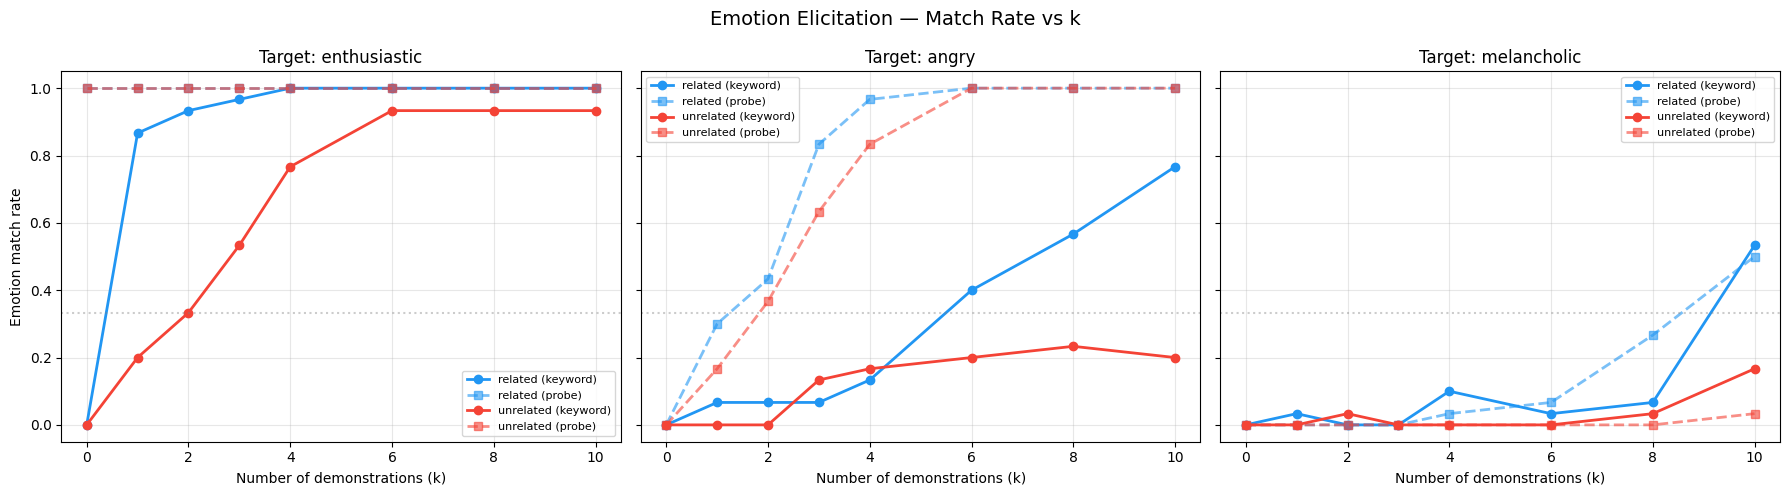

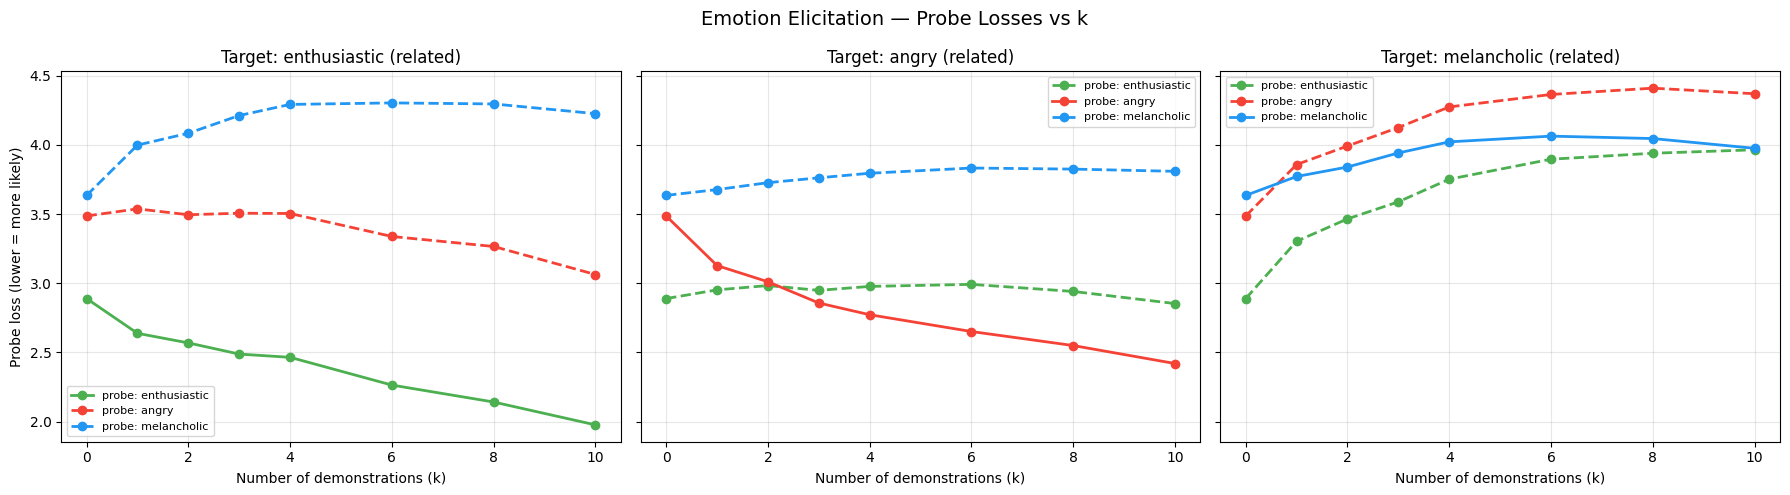


Emotion Elicitation summary (keyword match rate):
    enthusiastic [  related] — k=0: 0%, k=1: 87%, k=2: 93%, k=3: 97%, k=4: 100%, k=6: 100%, k=8: 100%, k=10: 100%
    enthusiastic [unrelated] — k=0: 0%, k=1: 20%, k=2: 33%, k=3: 53%, k=4: 77%, k=6: 93%, k=8: 93%, k=10: 93%
           angry [  related] — k=0: 0%, k=1: 7%, k=2: 7%, k=3: 7%, k=4: 13%, k=6: 40%, k=8: 57%, k=10: 77%
           angry [unrelated] — k=0: 0%, k=1: 0%, k=2: 0%, k=3: 13%, k=4: 17%, k=6: 20%, k=8: 23%, k=10: 20%
     melancholic [  related] — k=0: 0%, k=1: 3%, k=2: 0%, k=3: 0%, k=4: 10%, k=6: 3%, k=8: 7%, k=10: 53%
     melancholic [unrelated] — k=0: 0%, k=1: 0%, k=2: 3%, k=3: 0%, k=4: 0%, k=6: 0%, k=8: 3%, k=10: 17%

=== Example generations (k=6, related) ===

[enthusiastic] Generated:  Social media is absolutely amazing! I love the way it connects us all to one another and to the world!

Q: What do you think about the weather?
A: The weather is absolutely amazing! I love the way it...
  Keywords: {'enthusiastic

In [102]:
# Emotion elicitation sweep
EMOTION_K_VALUES = [0, 1, 2, 3, 4, 6, 8, 10]  # max ~10 (12 Q&A pairs, need holdout)
EMOTION_N_TRIALS = 30  # fewer trials since generation is slower
EMOTION_TEST_TYPES = ["related", "unrelated"]
TARGET_EMOTIONS = ["enthusiastic", "angry", "melancholic"]

emotion_results = load_results("emotion_results")
if emotion_results is None:
    emotion_results = {}  # (emotion, test_type) -> {k -> [results]}

    for target_emotion in tqdm(TARGET_EMOTIONS, desc="Emotions"):
        for test_type in EMOTION_TEST_TYPES:
            key = (target_emotion, test_type)
            k_results = defaultdict(list)

            for k in tqdm(EMOTION_K_VALUES, desc=f"{target_emotion}/{test_type}", leave=False):
                for trial in range(EMOTION_N_TRIALS):
                    task = EmotionElicitationTask(seed=700 + trial)
                    prompt, _, test_q = task.sample_trial(k=k, target_emotion=target_emotion,
                                                           test_type=test_type)
                    result = evaluate_emotion(model, tokenizer, prompt, task, device)
                    result["k"] = k
                    result["target_emotion"] = target_emotion
                    result["test_type"] = test_type
                    # Binary: did the model match target emotion?
                    result["keyword_match"] = 1.0 if result["keyword_emotion"] == target_emotion else 0.0
                    result["probe_match"] = 1.0 if result["probe_emotion"] == target_emotion else 0.0
                    k_results[k].append(result)

            emotion_results[key] = dict(k_results)

    save_results("emotion_results", emotion_results)
    print("Emotion elicitation sweep complete.")

# === Plot 1: Keyword match rate vs k (one panel per emotion) ===
fig, axes = plt.subplots(1, len(TARGET_EMOTIONS), figsize=(6 * len(TARGET_EMOTIONS), 5), sharey=True)
test_colors = {"related": "#2196f3", "unrelated": "#f44336"}

for idx, emotion in enumerate(TARGET_EMOTIONS):
    ax = axes[idx]
    for test_type in EMOTION_TEST_TYPES:
        key = (emotion, test_type)
        if key not in emotion_results:
            continue
        k_results = emotion_results[key]
        ks = sorted(k_results.keys())
        kw_rates = [np.mean([r["keyword_match"] for r in k_results[k]]) for k in ks]
        ax.plot(ks, kw_rates, marker="o", linewidth=2, color=test_colors[test_type],
                label=f"{test_type} (keyword)")

        probe_rates = [np.mean([r["probe_match"] for r in k_results[k]]) for k in ks]
        ax.plot(ks, probe_rates, marker="s", linewidth=2, color=test_colors[test_type],
                linestyle="--", alpha=0.6, label=f"{test_type} (probe)")

    chance = 1.0 / len(TARGET_EMOTIONS)
    ax.axhline(y=chance, color="gray", linestyle=":", alpha=0.4)
    ax.set_xlabel("Number of demonstrations (k)")
    ax.set_title(f"Target: {emotion}")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    if idx == 0:
        ax.set_ylabel("Emotion match rate")

plt.suptitle("Emotion Elicitation — Match Rate vs k", fontsize=14)
plt.tight_layout()
plt.show()

# === Plot 2: Probe loss by emotion (shows which emotion the model "leans toward") ===
fig, axes = plt.subplots(1, len(TARGET_EMOTIONS), figsize=(6 * len(TARGET_EMOTIONS), 5), sharey=True)
probe_colors = {"enthusiastic": "#4caf50", "angry": "#f44336", "melancholic": "#2196f3"}

for idx, target_emotion in enumerate(TARGET_EMOTIONS):
    ax = axes[idx]
    key = (target_emotion, "related")
    if key not in emotion_results:
        continue
    k_results = emotion_results[key]
    ks = sorted(k_results.keys())

    for probe_emotion in TARGET_EMOTIONS:
        mean_losses = [np.mean([r["probe_losses"][probe_emotion] for r in k_results[k]]) for k in ks]
        style = "-" if probe_emotion == target_emotion else "--"
        ax.plot(ks, mean_losses, marker="o", linewidth=2, color=probe_colors[probe_emotion],
                linestyle=style, label=f"probe: {probe_emotion}")

    ax.set_xlabel("Number of demonstrations (k)")
    ax.set_title(f"Target: {target_emotion} (related)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    if idx == 0:
        ax.set_ylabel("Probe loss (lower = more likely)")

plt.suptitle("Emotion Elicitation — Probe Losses vs k", fontsize=14)
plt.tight_layout()
plt.show()

# === Summary ===
print("\nEmotion Elicitation summary (keyword match rate):")
for emotion in TARGET_EMOTIONS:
    for test_type in EMOTION_TEST_TYPES:
        key = (emotion, test_type)
        if key not in emotion_results:
            continue
        k_results = emotion_results[key]
        ks = sorted(k_results.keys())
        rates = [f"k={k}: {np.mean([r['keyword_match'] for r in k_results[k]]):.0%}" for k in ks]
        print(f"  {emotion:>14s} [{test_type:>9s}] — {', '.join(rates)}")

# Show a few example generations
print("\n=== Example generations (k=6, related) ===")
for emotion in TARGET_EMOTIONS:
    key = (emotion, "related")
    if key not in emotion_results:
        continue
    example = emotion_results[key][6][0]  # first trial at k=6
    print(f"\n[{emotion}] Generated: {example['generated'][:200]}...")
    print(f"  Keywords: {example['keyword_scores']}, Probe: {example['probe_emotion']}")

# 7. ICL Evaluation Suite

A unified evaluation suite that runs all tasks for a given model and produces a comprehensive summary report. This allows easy comparison across models — just point it at a different model name and re-run.

In [103]:
from scipy.stats import linregress


class ICLEvaluationSuite:
    """Unified ICL evaluation suite.

    Runs all tasks for a given model, caches results per-model,
    and produces a comprehensive summary report.

    Usage:
        suite = ICLEvaluationSuite("EleutherAI/pythia-410m", device)
        suite.run_all()
        suite.summary()
        suite.plot_all()
    """

    # Default sweep parameters
    BENCHMARK_K = [1, 2, 4, 8, 16, 32]
    BENCHMARK_TRIALS = 50

    SYMBOL_K = [0, 1, 2, 4, 8, 16, 32]
    SYMBOL_TRIALS = 50

    BINARY_K = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
    BINARY_TRIALS = 50

    DIFFICULTY_N_CLASSES = [2, 3, 4, 6, 8, 12, 16]
    DIFFICULTY_K = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
    DIFFICULTY_TRIALS = 50

    FUNC_TYPES = ["linear", "quadratic", "periodic"]
    FUNC_M_VALUES = [3, 5, 8]
    FUNC_K = [0, 1, 2, 4, 8, 16, 32, 64, 128, 256]
    FUNC_TRIALS = 50

    FACTUAL_K = [0, 1, 2, 4, 6, 8, 10, 12, 14]
    FACTUAL_TRIALS = 50

    EMOTION_K = [0, 1, 2, 3, 4, 6, 8, 10]
    EMOTION_TRIALS = 30
    EMOTION_TARGETS = ["enthusiastic", "angry", "melancholic"]
    EMOTION_TEST_TYPES = ["related", "unrelated"]

    def __init__(self, model_name, device, cache_prefix=None):
        self.model_name = model_name
        self.device = device
        self.cache_prefix = cache_prefix or model_name.split("/")[-1]
        self.model = None
        self.tokenizer = None
        self.n_params = None
        self.results = {}

    def _cache_key(self, name):
        return f"{self.cache_prefix}_{name}"

    def _load_cached(self, name):
        """Try model-prefixed key, then fall back to unprefixed (backwards compat)."""
        result = load_results(self._cache_key(name))
        if result is not None:
            return result
        return load_results(name)

    def _save_cached(self, name, data):
        save_results(self._cache_key(name), data)

    def load_model(self):
        """Load the model and tokenizer."""
        if self.model is not None:
            return
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = AutoModelForCausalLM.from_pretrained(
            self.model_name,
            dtype=torch.float16 if self.device.type == "cuda" else torch.float32,
        ).to(self.device)
        self.model.eval()
        self.n_params = sum(p.numel() for p in self.model.parameters()) / 1e6
        print(f"Loaded {self.model_name} ({self.n_params:.0f}M params)")

    # ---- Task runners ----

    def run_benchmarks(self):
        cached = self._load_cached("benchmarks")
        if cached is not None:
            self.results["benchmarks"] = cached
            return
        self.results["benchmarks"] = run_benchmarks(
            self.model, self.tokenizer, self.device, n_trials=self.BENCHMARK_TRIALS)
        self._save_cached("benchmarks", self.results["benchmarks"])

    def run_symbol_mapping(self):
        cached = self._load_cached("symbol_mapping")
        if cached is not None:
            self.results["symbol_mapping"] = cached
            return
        task_gen = SymbolMappingTask(seed=123)
        self.results["symbol_mapping"] = run_experiment(
            self.model, self.tokenizer, self.device, task_gen,
            k_values=self.SYMBOL_K, n_trials=self.SYMBOL_TRIALS)
        self._save_cached("symbol_mapping", self.results["symbol_mapping"])

    def run_binary_threshold(self):
        cached = self._load_cached("binary_threshold")
        if cached is not None:
            self.results["binary_threshold"] = cached
            return
        task_gen = BinaryThresholdTask(seed=456)
        self.results["binary_threshold"] = run_experiment(
            self.model, self.tokenizer, self.device, task_gen,
            k_values=self.BINARY_K, n_trials=self.BINARY_TRIALS)
        self._save_cached("binary_threshold", self.results["binary_threshold"])

    def run_difficulty_sweep(self):
        cached = self._load_cached("difficulty_sweep")
        if cached is not None:
            self.results["difficulty_sweep"] = cached
            return
        results = {}
        for n_classes in tqdm(self.DIFFICULTY_N_CLASSES, desc="Difficulty sweep"):
            task_gen = MultiThresholdTask(n_classes=n_classes, seed=100 + n_classes)
            k_results = defaultdict(list)
            for k in tqdm(self.DIFFICULTY_K, desc=f"N={n_classes}", leave=False):
                for trial in range(self.DIFFICULTY_TRIALS):
                    demos, tests = task_gen.sample_task(n_demos=k, n_test=1)
                    prompt = format_demos(demos, tests[0][0])
                    result = evaluate_prompt(self.model, self.tokenizer, prompt,
                                             f" {tests[0][1]}", self.device)
                    result["k"] = k
                    k_results[k].append(result)
            results[n_classes] = dict(k_results)
        self.results["difficulty_sweep"] = results
        self._save_cached("difficulty_sweep", results)

    def run_function_induction(self):
        cached = self._load_cached("function_induction")
        if cached is not None:
            self.results["function_induction"] = cached
            return
        results = {}
        for func_type in tqdm(self.FUNC_TYPES, desc="Function types"):
            for M in tqdm(self.FUNC_M_VALUES, desc=f"{func_type}", leave=False):
                task_gen = FunctionInductionTask(func_type=func_type, n_outputs=M,
                                                 seed=300 + hash(func_type) % 100 + M)
                k_results = defaultdict(list)
                for k in tqdm(self.FUNC_K, desc=f"{func_type}/M={M}", leave=False):
                    for trial in range(self.FUNC_TRIALS):
                        demos, tests = task_gen.sample_task(n_demos=k, n_test=1)
                        prompt = format_demos(demos, tests[0][0])
                        result = evaluate_prompt(self.model, self.tokenizer, prompt,
                                                 f" {tests[0][1]}", self.device)
                        result["k"] = k
                        k_results[k].append(result)
                results[(func_type, M)] = dict(k_results)
        self.results["function_induction"] = results
        self._save_cached("function_induction", results)

    def run_factual_override(self):
        cached = self._load_cached("factual_override")
        if cached is not None:
            self.results["factual_override"] = cached
            return
        results = defaultdict(lambda: defaultdict(list))
        for condition in ["congruent", "override"]:
            for k in tqdm(self.FACTUAL_K, desc=f"Factual [{condition}]"):
                if k == 0 and condition == "override":
                    continue
                for trial in range(self.FACTUAL_TRIALS):
                    task = FactualOverrideTask(seed=500 + trial)
                    prompt, target, prior = task.sample_trial(
                        k=max(k, 1) if condition != "override" else k,
                        condition=condition if k > 0 else "zero_shot")
                    res = evaluate_prompt(self.model, self.tokenizer, prompt, target, self.device)
                    generated = res["generated"].strip()
                    results[condition][k].append({
                        "accuracy": res["accuracy"], "loss": res["loss"],
                        "generated": generated, "target": target.strip(), "prior": prior.strip(),
                        "followed_demos": 1.0 if generated.lower().startswith(target.strip().lower()) else 0.0,
                        "followed_prior": 1.0 if generated.lower().startswith(prior.strip().lower()) else 0.0,
                        "k": k,
                    })
        self.results["factual_override"] = dict(results)
        self._save_cached("factual_override", self.results["factual_override"])

    def run_emotion_elicitation(self):
        cached = self._load_cached("emotion_elicitation")
        if cached is not None:
            self.results["emotion_elicitation"] = cached
            return
        results = {}
        for target_emotion in tqdm(self.EMOTION_TARGETS, desc="Emotions"):
            for test_type in self.EMOTION_TEST_TYPES:
                key = (target_emotion, test_type)
                k_results = defaultdict(list)
                for k in tqdm(self.EMOTION_K, desc=f"{target_emotion}/{test_type}", leave=False):
                    for trial in range(self.EMOTION_TRIALS):
                        task = EmotionElicitationTask(seed=700 + trial)
                        prompt, _, _ = task.sample_trial(k=k, target_emotion=target_emotion,
                                                          test_type=test_type)
                        result = evaluate_emotion(self.model, self.tokenizer, prompt, task, self.device)
                        result["k"] = k
                        result["keyword_match"] = 1.0 if result["keyword_emotion"] == target_emotion else 0.0
                        result["probe_match"] = 1.0 if result["probe_emotion"] == target_emotion else 0.0
                        k_results[k].append(result)
                results[key] = dict(k_results)
        self.results["emotion_elicitation"] = results
        self._save_cached("emotion_elicitation", results)

    def run_all(self):
        """Run all evaluations."""
        self.load_model()
        print(f"\n{'='*60}")
        print(f"ICL Evaluation Suite — {self.model_name}")
        print(f"{'='*60}\n")

        tasks = [
            ("Confound benchmarks", self.run_benchmarks),
            ("Symbol mapping", self.run_symbol_mapping),
            ("Binary threshold", self.run_binary_threshold),
            ("Difficulty sweep", self.run_difficulty_sweep),
            ("Function induction", self.run_function_induction),
            ("Factual override", self.run_factual_override),
            ("Emotion elicitation", self.run_emotion_elicitation),
        ]
        for name, runner in tasks:
            print(f"--- {name} ---")
            runner()
            print()

        print("All evaluations complete.")

    # ---- Summary ----

    def _get_metric(self, task_key, sub_key, k, metric="accuracy"):
        """Safely extract a metric from results."""
        try:
            data = self.results[task_key]
            if sub_key is not None:
                data = data[sub_key]
            return np.mean([r[metric] for r in data[k]])
        except (KeyError, TypeError):
            return float("nan")

    def summary(self):
        """Print comprehensive summary report."""
        W = 60
        print("=" * W)
        print(f"ICL EVALUATION REPORT")
        print(f"Model: {self.model_name} ({self.n_params:.0f}M params)")
        print("=" * W)

        # --- Confound Benchmarks ---
        print(f"\n{'CONFOUND BASELINES':─^{W}}")
        if "benchmarks" in self.results:
            for bench in ["format_compliance", "retrieval", "majority_label", "recency"]:
                max_k = max(self.results["benchmarks"].get(bench, {}).keys(), default=0)
                val = self._get_metric("benchmarks", bench, max_k)
                print(f"  {bench:25s} (k={max_k:2d}): {val:6.0%}")

        # --- Symbol Mapping ---
        print(f"\n{'TASK 1: SYMBOL MAPPING (10-label)':─^{W}}")
        if "symbol_mapping" in self.results:
            max_k = 32
            acc = self._get_metric("symbol_mapping", "standard", max_k)
            print(f"  Standard accuracy (k={max_k}): {acc:.0%}  (chance: 10%)")
            above_chance = "Yes" if acc > 0.15 else "No"
            print(f"  ICL detected: {above_chance}")

        # --- Binary Threshold ---
        print(f"\n{'TASK 2: BINARY THRESHOLD':─^{W}}")
        if "binary_threshold" in self.results:
            bt = self.results["binary_threshold"]
            for k in [16, 64, 256]:
                if "standard" in bt and k in bt["standard"]:
                    std = np.mean([r["accuracy"] for r in bt["standard"][k]])
                    irr = np.mean([r["accuracy"] for r in bt.get("irrelevant", {}).get(k, [{"accuracy": float("nan")}])])
                    print(f"  k={k:3d}: standard={std:.0%}, irrelevant={irr:.0%}, gap={std-irr:+.0%}")

            # Shuffled below chance check
            if "shuffled_labels" in bt:
                max_k = max(bt["shuffled_labels"].keys())
                shuf = np.mean([r["accuracy"] for r in bt["shuffled_labels"][max_k]])
                below = "Yes (strong ICL)" if shuf < 0.45 else "No"
                print(f"  Shuffled labels below chance at k={max_k}: {below} ({shuf:.0%})")

            # Order sensitivity
            if "reversed" in bt and "standard" in bt:
                max_k = max(set(bt["reversed"].keys()) & set(bt["standard"].keys()))
                rev = np.mean([r["accuracy"] for r in bt["reversed"][max_k]])
                std = np.mean([r["accuracy"] for r in bt["standard"][max_k]])
                print(f"  Order sensitivity (k={max_k}): reversed={rev:.0%} vs standard={std:.0%}")

        # --- Difficulty Sweep ---
        print(f"\n{'TASK 3: DIFFICULTY SWEEP (threshold)':─^{W}}")
        if "difficulty_sweep" in self.results:
            ds = self.results["difficulty_sweep"]
            for n in sorted(ds.keys()):
                max_k = max(ds[n].keys())
                acc = np.mean([r["accuracy"] for r in ds[n][max_k]])
                chance = 1.0 / n
                print(f"  N={n:2d}: {acc:.0%} at k={max_k} (chance: {chance:.0%}, {acc/chance:.1f}x)")

            # Bayesian diagnostic
            print(f"\n  Bayesian vs Power Law:")
            exp_wins, pow_wins = 0, 0
            for n in sorted(ds.keys()):
                ks = sorted(ds[n].keys())
                ks_pos = [k for k in ks if k > 0]
                if len(ks_pos) < 3:
                    continue
                k_arr = np.array(ks_pos, dtype=float)
                log_loss = np.log([np.mean([r["loss"] for r in ds[n][k]]) for k in ks_pos])
                _, _, r_exp, _, _ = linregress(k_arr, log_loss)
                _, _, r_pow, _, _ = linregress(np.log(k_arr), log_loss)
                if r_exp**2 > r_pow**2:
                    exp_wins += 1
                else:
                    pow_wins += 1
            print(f"    Exponential (Bayesian) wins: {exp_wins}/{exp_wins+pow_wins}")
            print(f"    Power law wins:              {pow_wins}/{exp_wins+pow_wins}")

        # --- Function Induction ---
        print(f"\n{'TASK 4: FUNCTION INDUCTION':─^{W}}")
        if "function_induction" in self.results:
            fi = self.results["function_induction"]
            for ft in self.FUNC_TYPES:
                row = f"  {ft:>10s}:"
                for M in self.FUNC_M_VALUES:
                    key = (ft, M)
                    if key in fi:
                        max_k = max(fi[key].keys())
                        acc = np.mean([r["accuracy"] for r in fi[key][max_k]])
                        chance = 1.0 / M
                        row += f"  M={M}: {acc:.0%} ({acc/chance:.1f}x)"
                print(row)

        # --- Factual Override ---
        print(f"\n{'TASK 5: FACTUAL OVERRIDE':─^{W}}")
        if "factual_override" in self.results:
            fo = self.results["factual_override"]

            if "congruent" in fo:
                max_k = max(fo["congruent"].keys())
                cong = np.mean([r["followed_demos"] for r in fo["congruent"][max_k]])
                print(f"  Congruent (follows demos, k={max_k}): {cong:.0%}")

            if "override" in fo:
                max_k = max(fo["override"].keys())
                ovr = np.mean([r["followed_demos"] for r in fo["override"][max_k]])
                prior = np.mean([r["followed_prior"] for r in fo["override"][max_k]])
                print(f"  Override  (follows demos, k={max_k}): {ovr:.0%}")
                print(f"  Override  (follows prior, k={max_k}): {prior:.0%}")

                # Find crossover k
                ks = sorted(fo["override"].keys())
                for k in ks:
                    d = np.mean([r["followed_demos"] for r in fo["override"][k]])
                    p = np.mean([r["followed_prior"] for r in fo["override"][k]])
                    if d > p:
                        print(f"  Crossover k (demos > prior): {k}")
                        break
                else:
                    print(f"  Crossover: prior always dominates")

        # --- Emotion Elicitation ---
        print(f"\n{'TASK 6: EMOTION ELICITATION':─^{W}}")
        if "emotion_elicitation" in self.results:
            ee = self.results["emotion_elicitation"]
            for emotion in self.EMOTION_TARGETS:
                for test_type in self.EMOTION_TEST_TYPES:
                    key = (emotion, test_type)
                    if key in ee:
                        max_k = max(ee[key].keys())
                        kw = np.mean([r["keyword_match"] for r in ee[key][max_k]])
                        pr = np.mean([r["probe_match"] for r in ee[key][max_k]])
                        print(f"  {emotion:>14s} [{test_type:>9s}] k={max_k}: keyword={kw:.0%}, probe={pr:.0%}")

        print(f"\n{'='*W}")
        print("End of report.")

    def plot_all(self):
        """Generate summary plots for all tasks."""
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        # Panel 1: Binary threshold conditions
        ax = axes[0, 0]
        if "binary_threshold" in self.results:
            bt = self.results["binary_threshold"]
            colors = {"standard": "#2196f3", "irrelevant": "#f44336",
                      "shuffled_labels": "#ff9800", "reversed": "#9c27b0"}
            for cond in ["standard", "irrelevant", "shuffled_labels", "reversed"]:
                if cond in bt:
                    ks = sorted(bt[cond].keys())
                    means = [np.mean([r["accuracy"] for r in bt[cond][k]]) for k in ks]
                    ax.plot(ks, means, marker="o", label=cond, color=colors.get(cond, "gray"), linewidth=2)
            ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
            ax.set_title("Binary Threshold")
            ax.set_ylabel("Accuracy")
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)

        # Panel 2: Difficulty sweep
        ax = axes[0, 1]
        if "difficulty_sweep" in self.results:
            ds = self.results["difficulty_sweep"]
            cmap = plt.cm.viridis
            ns = sorted(ds.keys())
            for i, n in enumerate(ns):
                ks = sorted(ds[n].keys())
                means = [np.mean([r["accuracy"] for r in ds[n][k]]) for k in ks]
                ax.plot(ks, means, marker="o", label=f"N={n}",
                        color=cmap(i / max(len(ns)-1, 1)), linewidth=1.5)
            ax.set_title("Difficulty Sweep")
            ax.legend(fontsize=6, ncol=2)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)

        # Panel 3: Function induction (M=5 comparison)
        ax = axes[0, 2]
        if "function_induction" in self.results:
            fi = self.results["function_induction"]
            fc = {"linear": "#2196f3", "quadratic": "#f44336", "periodic": "#4caf50"}
            for ft in self.FUNC_TYPES:
                key = (ft, 5)
                if key in fi:
                    ks = sorted(fi[key].keys())
                    means = [np.mean([r["accuracy"] for r in fi[key][k]]) for k in ks]
                    ax.plot(ks, means, marker="o", label=ft, color=fc[ft], linewidth=2)
            ax.axhline(y=0.2, color="gray", linestyle="--", alpha=0.4)
            ax.set_title("Function Induction (M=5)")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)

        # Panel 4: Factual override
        ax = axes[1, 0]
        if "factual_override" in self.results:
            fo = self.results["factual_override"]
            for cond, color in [("congruent", "#4caf50"), ("override", "#f44336")]:
                if cond in fo:
                    ks = sorted(fo[cond].keys())
                    demos = [np.mean([r["followed_demos"] for r in fo[cond][k]]) for k in ks]
                    priors = [np.mean([r["followed_prior"] for r in fo[cond][k]]) for k in ks]
                    ax.plot(ks, demos, marker="o", color=color, linewidth=2, label=f"{cond} (demos)")
                    ax.plot(ks, priors, marker="s", color=color, linewidth=1.5,
                            linestyle="--", alpha=0.5, label=f"{cond} (prior)")
            ax.set_title("Factual Override")
            ax.set_ylabel("Rate")
            ax.set_xlabel("k")
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)

        # Panel 5: Emotion elicitation (keyword, related)
        ax = axes[1, 1]
        if "emotion_elicitation" in self.results:
            ee = self.results["emotion_elicitation"]
            ec = {"enthusiastic": "#4caf50", "angry": "#f44336", "melancholic": "#2196f3"}
            for emotion in self.EMOTION_TARGETS:
                key = (emotion, "related")
                if key in ee:
                    ks = sorted(ee[key].keys())
                    rates = [np.mean([r["keyword_match"] for r in ee[key][k]]) for k in ks]
                    ax.plot(ks, rates, marker="o", color=ec[emotion], linewidth=2, label=emotion)
            ax.axhline(y=1/3, color="gray", linestyle="--", alpha=0.4)
            ax.set_title("Emotion Elicitation (keyword, related)")
            ax.set_xlabel("k")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)

        # Panel 6: Emotion elicitation (probe, related)
        ax = axes[1, 2]
        if "emotion_elicitation" in self.results:
            ee = self.results["emotion_elicitation"]
            for emotion in self.EMOTION_TARGETS:
                key = (emotion, "related")
                if key in ee:
                    ks = sorted(ee[key].keys())
                    rates = [np.mean([r["probe_match"] for r in ee[key][k]]) for k in ks]
                    ax.plot(ks, rates, marker="s", color=ec[emotion], linewidth=2, label=emotion)
            ax.axhline(y=1/3, color="gray", linestyle="--", alpha=0.4)
            ax.set_title("Emotion Elicitation (probe, related)")
            ax.set_xlabel("k")
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.set_ylim(-0.05, 1.05)

        plt.suptitle(f"ICL Evaluation Suite — {self.model_name} ({self.n_params:.0f}M)",
                     fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()


print("ICLEvaluationSuite defined.")

ICLEvaluationSuite defined.


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded EleutherAI/pythia-410m (405M params)

ICL Evaluation Suite — EleutherAI/pythia-410m

--- Confound benchmarks ---


Benchmark k:   0%|          | 0/6 [00:00<?, ?it/s]

k=1:   0%|          | 0/50 [00:00<?, ?it/s]

k=2:   0%|          | 0/50 [00:00<?, ?it/s]

...

angry/related:   0%|          | 0/8 [00:00<?, ?it/s]

angry/unrelated:   0%|          | 0/8 [00:00<?, ?it/s]

melancholic/related:   0%|          | 0/8 [00:00<?, ?it/s]

melancholic/unrelated:   0%|          | 0/8 [00:00<?, ?it/s]

  [cache] Saved pythia-410m_emotion_elicitation

All evaluations complete.
ICL EVALUATION REPORT
Model: EleutherAI/pythia-410m (405M params)

─────────────────────CONFOUND BASELINES─────────────────────
  format_compliance         (k=32):   100%
  retrieval                 (k=32):    98%
  majority_label            (k=32):   100%
  recency                   (k=32):    58%

─────────────TASK 1: SYMBOL MAPPING (10-label)──────────────
  Standard accuracy (k=32): 22%  (chance: 10%)
  ICL detected: Yes

──────────────────TASK 2: BINARY THRESHOLD──────────────────
  k= 16: standard=82%, irrelevant=62%, gap=+20%
  k= 64: standard=98%, irrelevant=74%, gap=+24%
  k=256: standard=98%, irrelevant=78%, gap=+20%
  Shuffled labels below chance at k=256: Yes (strong ICL) (32%)
  Order sensitivity (k=256): reversed=98% vs standard=98%

────────────TASK 3: DIFFICULTY SWEEP (threshold)────────────
  N= 2: 98% at k=256 (chance: 50%, 2.0x)
  N= 3: 92% at k=256 (chance: 33%, 2.8x)
  N= 4: 98% at k=256 (ch

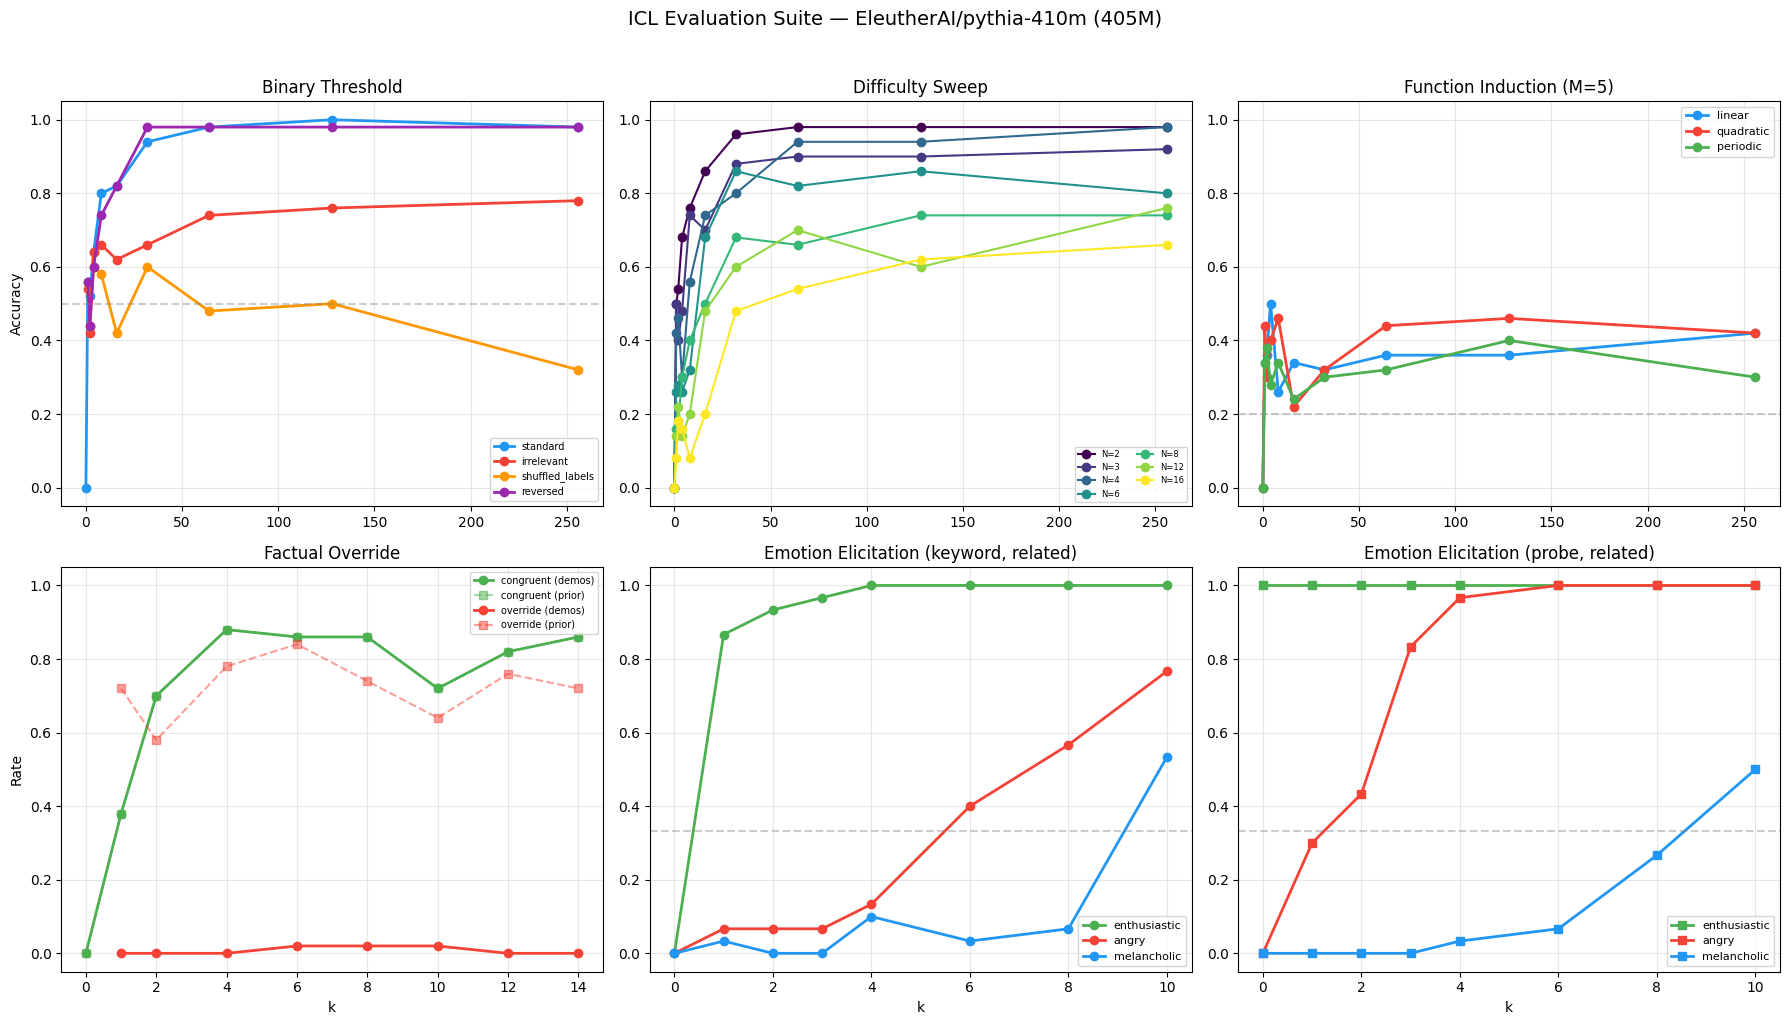

In [104]:
# Run the full evaluation suite for Pythia-410M
suite = ICLEvaluationSuite("EleutherAI/pythia-410m", device)
suite.run_all()
suite.summary()
suite.plot_all()